# I-JEPA vs. MAE on RetinaMNIST — a guided, from-scratch comparison

Two self-supervised objectives, one identical backbone, one small medical dataset.

**The question this notebook answers is not "which one wins?"** — at this scale nobody
wins convincingly. The question is: *what do these two objectives actually do, and how
does that difference show up in the features they produce?*

| | MAE (Masked Autoencoder) | I-JEPA (Joint-Embedding Predictive Architecture) |
|---|---|---|
| Hide | 75% of patches, randomly scattered | ~4 contiguous blocks |
| Predict | **pixels** of the hidden patches | **latent features** of the hidden blocks |
| Target comes from | the input image itself | a slowly-moving **EMA copy** of the encoder |
| Needs a decoder? | yes, a pixel decoder | no — a narrow latent predictor |
| Failure mode to avoid | none (pixels are a fixed target) | **collapse** (predict a constant) — EMA + stop-grad prevent it |
| Can you *look* at what it learned? | yes, reconstructions | no, there is no picture |

That last row is the whole story in miniature, and section 7 makes it concrete.

**What we build, in order**

0. Setup, device, MPS caveats
1. Config (every knob in one cell)
2. Data — load RetinaMNIST, print its *real* stats, look at actual fundus images
3. The shared ViT backbone (both methods get the *same* class, same config)
4. MAE: implementation → training → loss curve
5. I-JEPA: masking → implementation → training → loss curve + collapse monitor
6. Frozen-feature evaluation: linear probe + kNN, side by side
7. MAE reconstructions (and why JEPA has no equivalent image)
8. Noise-robustness sweep — the key experiment
9. Sample efficiency — accuracy vs. number of labels
10. Honest caveats and durable takeaways

Everything runs top-to-bottom with **Run All**, on a MacBook, on the MPS backend.

---
## 0. Setup, device, and MPS caveats

The next cell must run **before** `import torch`: it sets the MPS fallback flag, so any
op Apple's Metal backend hasn't implemented silently runs on CPU instead of raising.
Then we install anything missing. The install is guarded — if the import already works,
nothing happens.

Note on the installer: some environments (uv-managed venvs) have no `pip` module, so we
try `pip` first and fall back to `uv pip`.

In [27]:
import os

# MUST be set before torch is imported: unimplemented MPS ops fall back to CPU
# instead of crashing the kernel.
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
# Keep BLAS/OMP from oversubscribing cores on a laptop.
os.environ.setdefault("OMP_NUM_THREADS", "4")

import subprocess
import sys


def ensure(module: str, package: str | None = None) -> bool:
    """Import-guarded install. Returns True if the module is importable afterwards."""
    package = package or module
    try:
        __import__(module)
        return True
    except ImportError:
        pass
    print(f"[setup] installing {package} ...")
    for cmd in (
        [sys.executable, "-m", "pip", "install", "-q", package],
        ["uv", "pip", "install", "--python", sys.executable, package],
    ):
        try:
            if subprocess.call(cmd, stdout=subprocess.DEVNULL) == 0:
                break
        except FileNotFoundError:
            continue
    try:
        __import__(module)
        return True
    except ImportError:
        print(f"[setup] WARNING: could not install {package}")
        return False


for mod, pkg in [
    ("numpy", "numpy"),
    ("torch", "torch"),
    ("torchvision", "torchvision"),
    ("matplotlib", "matplotlib"),
    ("sklearn", "scikit-learn"),
    ("tqdm", "tqdm"),
    ("medmnist", "medmnist"),
]:
    ensure(mod, pkg)

ensure("timm", "timm")  # optional, not required by any cell below
print("[setup] done")

[setup] done


### Device and the three MPS rules we follow everywhere

1. **float32 only.** MPS does not support float64, so we never let a tensor become
   double. Every image tensor is cast explicitly.
2. **No AMP / autocast.** Mixed precision on MPS is unreliable; the models here are
   tiny enough that it buys nothing.
3. **`num_workers=0`, `pin_memory=False`.** macOS forks processes for DataLoader workers
   and pinned memory is a CUDA concept; both cause more trouble than they save here.

One more thing worth knowing up front: **MPS is not bit-for-bit deterministic.** We seed
`torch`, `numpy`, and `random`, but reduction order on the GPU can vary, so re-running
this notebook will give you slightly different numbers — a few tenths of a percent on
the probes, sometimes more on a 400-image test set. Any difference between MAE and JEPA
smaller than that gap is noise, not a finding.

In [28]:
import copy
import json
import math
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"torch          : {torch.__version__}")
print(f"mps available  : {torch.backends.mps.is_available()}")
print(f"mps built      : {torch.backends.mps.is_built()}")
print(f"==> DEVICE     : {DEVICE}")
if DEVICE.type == "cpu":
    print("    (no MPS — everything still runs, just slower)")

torch.set_default_dtype(torch.float32)  # rule 1: float32 everywhere

OUTDIR = Path("./outputs")
OUTDIR.mkdir(exist_ok=True, parents=True)
print(f"plots + tables -> {OUTDIR.resolve()}")


def set_seed(seed: int) -> None:
    """Seed every RNG we touch. MPS is still not fully deterministic (see note above)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


TIMINGS: dict[str, float] = {}


class Phase:
    """Context manager that reports and records wall-clock time for a phase."""

    def __init__(self, name: str):
        self.name = name

    def __enter__(self):
        print(f"\n=== {self.name} ===")
        self.t0 = time.time()
        return self

    def __exit__(self, *exc):
        dt = time.time() - self.t0
        TIMINGS[self.name] = dt
        print(f"=== {self.name}: {dt:.1f}s wall-clock ({dt / 60:.2f} min) ===")
        return False

torch          : 2.13.0
mps available  : True
mps built      : True
==> DEVICE     : mps
plots + tables -> /Users/atharvax/dev/til/papers/JEPA/outputs


### Plot style

One place for the visual language, so every figure in the notebook reads as the same
system. Four series appear throughout — MAE, I-JEPA (the online context encoder),
I-JEPA's EMA teacher, and an untrained random-init encoder as a floor. The three
trained methods get the three categorical hues; the baseline gets neutral gray,
because a control is not a competitor. Each series also carries its own marker, so
identity never depends on color alone.

In [29]:
COLORS = {
    "MAE": "#2a78d6",  # blue
    "I-JEPA": "#eb6834",  # orange
    "I-JEPA (EMA teacher)": "#1baf7a",  # aqua
    "Random init": "#8a8a85",  # neutral gray — a control, not a series
}
MARKERS = {
    "MAE": "o",
    "I-JEPA": "s",
    "I-JEPA (EMA teacher)": "^",
    "Random init": "x",
}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#dcdcd8"

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK2,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.labelsize": 9.5,
        "xtick.color": INK2,
        "ytick.color": INK2,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
        "lines.markersize": 6.0,
        "font.size": 10,
    }
)


def style_axes(ax, ygrid: bool = True) -> None:
    """Recessive grid, no top/right spines. Data first, furniture second."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if ygrid:
        ax.grid(axis="y", color=GRID, linewidth=0.6, alpha=0.9)
        ax.set_axisbelow(True)


def save_fig(fig, name: str) -> None:
    path = OUTDIR / name
    fig.savefig(path)
    print(f"[saved] {path}")

---
## 1. Config — every knob in one cell

Nothing below this cell hardcodes a hyperparameter. The rule that makes the comparison
fair: **MAE and JEPA read the same `EPOCHS`, `BATCH_SIZE`, `LR`, `WEIGHT_DECAY`,
`WARMUP_EPOCHS`, `SEED`, and the same encoder config.** The only difference between the
two runs is the loss function and the small head attached to the encoder.

Defaults are chosen to finish in a few minutes on an Apple-Silicon laptop, not to
maximize accuracy. The knobs most worth turning later are called out in the comments.

In [30]:
CONFIG = {
    # ---- data -------------------------------------------------------------
    # ONE-LINE SWITCH for a much stronger SSL signal (PathMNIST: ~90k train images,
    # 9 classes). Just change this string and Run All — nothing else needs editing.
    # Options used/tested here: "retinamnist" (1,080 train) | "pathmnist" (89,996 train)
    "dataset": "retinamnist",
    "img_size": 64,  # medmnist serves 28/64/128/224; bump to 128 later (also raise patch to 16)
    "num_workers": 0,  # macOS: keep 0 (2 max)
    # ---- shared ViT backbone (IDENTICAL for both methods) -----------------
    "patch_size": 8,  # 64 / 8 -> 8x8 = 64 patches
    "embed_dim": 192,  # ViT-Tiny width
    "depth": 6,
    "num_heads": 3,
    "mlp_ratio": 4.0,
    # ---- shared optimization (IDENTICAL for both methods) -----------------
    "epochs": 100,
    "batch_size": 64,
    "lr": 1.5e-3,
    "min_lr": 1e-6,
    "weight_decay": 0.05,
    "warmup_epochs": 10,
    "seed": 0,
    # ---- MAE-specific ----------------------------------------------------
    "mae_mask_ratio": 0.75,
    "mae_decoder_dim": 96,  # shallow + narrow decoder, as in the paper
    "mae_decoder_depth": 3,
    "mae_decoder_heads": 3,
    # Per-patch normalized pixel targets (MAE paper's default). True usually helps
    # representation quality; False keeps the reconstruction grid in section 7 directly
    # viewable without borrowing ground-truth patch statistics.
    "mae_norm_pix_loss": False,
    # ---- I-JEPA-specific -------------------------------------------------
    "jepa_pred_dim": 96,  # NARROW predictor (bottleneck is deliberate)
    "jepa_pred_depth": 3,
    "jepa_pred_heads": 3,
    "jepa_num_targets": 4,  # ~4 target blocks per image
    "jepa_target_scale": (0.15, 0.2),  # fraction of the patch grid per target block
    "jepa_target_ar": (0.75, 1.5),  # aspect-ratio range for target blocks
    "jepa_context_scale": (0.85, 1.0),  # one large context block, then targets removed
    "jepa_ema": 0.996,  # base momentum for the teacher
    "jepa_ema_cosine": True,  # cosine-schedule momentum 0.996 -> 1.0
    # ---- evaluation ------------------------------------------------------
    "knn_k": 20,
    "knn_metric": "cosine",
    "noise_sigmas": (0.0, 0.05, 0.1, 0.2, 0.3, 0.4),
    "label_fractions": (0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 1.0),
    "label_repeats": 3,  # average sample-efficiency curves over this many subsamples
    "eval_batch_size": 256,
    "noise_seed": 1234,  # fixed, so every method sees the SAME noise realisation
}

GRID_SIZE = CONFIG["img_size"] // CONFIG["patch_size"]
NUM_PATCHES = GRID_SIZE * GRID_SIZE
assert CONFIG["img_size"] % CONFIG["patch_size"] == 0, "img_size must be divisible by patch_size"

print(json.dumps({k: str(v) for k, v in CONFIG.items()}, indent=2))
print(f"\npatch grid     : {GRID_SIZE} x {GRID_SIZE} = {NUM_PATCHES} tokens per image")
print(f"MAE visible    : {int(NUM_PATCHES * (1 - CONFIG['mae_mask_ratio']))} / {NUM_PATCHES} tokens")

# Rough runtime estimate. The per-step constants were measured on an Apple M-series
# laptop at these defaults; they scale roughly with tokens x width x depth. JEPA costs
# more per step because it runs the teacher on the full image and the predictor once per
# target block. Actual wall-clock is printed by every `Phase` block as we go, and tqdm
# shows a live ETA.
_scale = (NUM_PATCHES / 64) * (CONFIG["embed_dim"] / 192) * (CONFIG["depth"] / 6)
MS_PER_STEP = {"MAE": 44.0 * _scale, "I-JEPA": 98.0 * _scale * (CONFIG["jepa_num_targets"] / 4)}
print("\nmeasured cost  : " + ", ".join(f"{k} ~{v:.0f}ms/step" for k, v in MS_PER_STEP.items())
      + "  (on MPS, at this config)")

{
  "dataset": "retinamnist",
  "img_size": "64",
  "num_workers": "0",
  "patch_size": "8",
  "embed_dim": "192",
  "depth": "6",
  "num_heads": "3",
  "mlp_ratio": "4.0",
  "epochs": "100",
  "batch_size": "64",
  "lr": "0.0015",
  "min_lr": "1e-06",
  "weight_decay": "0.05",
  "warmup_epochs": "10",
  "seed": "0",
  "mae_mask_ratio": "0.75",
  "mae_decoder_dim": "96",
  "mae_decoder_depth": "3",
  "mae_decoder_heads": "3",
  "mae_norm_pix_loss": "False",
  "jepa_pred_dim": "96",
  "jepa_pred_depth": "3",
  "jepa_pred_heads": "3",
  "jepa_num_targets": "4",
  "jepa_target_scale": "(0.15, 0.2)",
  "jepa_target_ar": "(0.75, 1.5)",
  "jepa_context_scale": "(0.85, 1.0)",
  "jepa_ema": "0.996",
  "jepa_ema_cosine": "True",
  "knn_k": "20",
  "knn_metric": "cosine",
  "noise_sigmas": "(0.0, 0.05, 0.1, 0.2, 0.3, 0.4)",
  "label_fractions": "(0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 1.0)",
  "label_repeats": "3",
  "eval_batch_size": "256",
  "noise_seed": "1234"
}

patch grid     : 8 x 8 = 64 toke

---
## 2. Data — RetinaMNIST, and what it actually contains

RetinaMNIST is retinal fundus photography graded for **diabetic retinopathy severity on
a 5-point ordinal scale** (0 = no DR → 4 = proliferative). Two things about it shape
everything downstream, so we print them rather than assume them:

- **It is small.** Roughly a thousand training images. Self-supervised learning is a
  data-hungry regime; a thousand images is far below where either of these methods was
  designed to operate. Expect a weak, noisy signal — that is a property of the dataset,
  not a bug in the code.
- **It is imbalanced.** The mild/no-DR grades dominate. Plain accuracy is therefore
  flattering: a classifier that only ever predicts the majority class already scores
  well. We print that majority-class baseline and report **balanced accuracy** alongside
  plain accuracy everywhere.

**Protocol, stated once and obeyed throughout:** pretraining sees the **train split
only**, with no labels. Probes are fit on **train** features/labels and evaluated on
**test**. No test image ever enters pretraining.

Two transform pipelines:
- **SSL pretraining**: random resized crop + horizontal flip + light color jitter. The
  augmentation is what makes the masking task non-trivial.
- **Evaluation**: deterministic. Resize + normalize, nothing else. A probe measured
  through random crops would be measuring the crops.

In [32]:
import medmnist
from medmnist import INFO
from torchvision import transforms

DATA_FLAG = CONFIG["dataset"]
info = INFO[DATA_FLAG]
DataClass = getattr(medmnist, info["python_class"])
CLASS_LABELS = [v for _, v in sorted(info["label"].items(), key=lambda kv: int(kv[0]))]
NUM_CLASSES = len(CLASS_LABELS)

with Phase("2. load dataset"):
    raw_splits = {
        s: DataClass(split=s, download=True, size=CONFIG["img_size"], as_rgb=True)
        for s in ("train", "val", "test")
    }

print(f"\ndataset        : {DATA_FLAG}  ({info['description'].splitlines()[0][:110]}...)")
print(f"task           : {info['task']}")
print(f"channels       : {info['n_channels']}  (loaded as_rgb -> 3)")
print(f"classes        : {NUM_CLASSES}")
for i, name in enumerate(CLASS_LABELS):
    print(f"   {i}: {name}")

print("\nsplit sizes and class balance (printed from the real arrays, not hardcoded):")
for split, ds in raw_splits.items():
    y = np.asarray(ds.labels).reshape(-1)
    counts = np.bincount(y, minlength=NUM_CLASSES)
    pct = 100 * counts / counts.sum()
    print(f"  {split:5s} n={len(ds):6d}  raw image array {tuple(np.asarray(ds.imgs).shape)}")
    print(f"        counts {counts.tolist()}   pct {[f'{p:.1f}' for p in pct]}")

_ytest = np.asarray(raw_splits["test"].labels).reshape(-1)
MAJORITY_ACC = np.bincount(_ytest, minlength=NUM_CLASSES).max() / len(_ytest)
print(f"\nmajority-class baseline on TEST: {MAJORITY_ACC:.4f}  <- any probe must beat this to mean anything")


=== 2. load dataset ===
=== 2. load dataset: 0.1s wall-clock (0.00 min) ===

dataset        : retinamnist  (The RetinaMNIST is based on the DeepDRiD challenge, which provides a dataset of 1,600 retina fundus images. Th...)
task           : ordinal-regression
channels       : 3  (loaded as_rgb -> 3)
classes        : 5
   0: 0
   1: 1
   2: 2
   3: 3
   4: 4

split sizes and class balance (printed from the real arrays, not hardcoded):
  train n=  1080  raw image array (1080, 64, 64, 3)
        counts [486, 128, 206, 194, 66]   pct ['45.0', '11.9', '19.1', '18.0', '6.1']
  val   n=   120  raw image array (120, 64, 64, 3)
        counts [54, 12, 28, 20, 6]   pct ['45.0', '10.0', '23.3', '16.7', '5.0']
  test  n=   400  raw image array (400, 64, 64, 3)
        counts [174, 46, 92, 68, 20]   pct ['43.5', '11.5', '23.0', '17.0', '5.0']

majority-class baseline on TEST: 0.4350  <- any probe must beat this to mean anything


In [33]:
def to_float_tensor(imgs: np.ndarray) -> torch.Tensor:
    """uint8 (N,H,W) or (N,H,W,C) -> float32 (N,3,H,W) in [0,1]. Explicit float32: MPS rule 1."""
    a = np.asarray(imgs)
    if a.ndim == 3:  # grayscale dataset -> replicate to 3 channels
        a = np.repeat(a[..., None], 3, axis=-1)
    t = torch.from_numpy(np.ascontiguousarray(a)).permute(0, 3, 1, 2).contiguous()
    return t.to(torch.float32).div_(255.0)


# Raw [0,1] eval tensors, kept on CPU. Small enough to hold in memory, and having them
# as plain tensors is what lets section 8 inject noise in *pixel* space before normalizing.
EVAL_IMGS = {s: to_float_tensor(ds.imgs) for s, ds in raw_splits.items()}
EVAL_LABELS = {s: np.asarray(ds.labels).reshape(-1) for s, ds in raw_splits.items()}

# Normalization statistics computed from the TRAIN split (never from test).
MEAN = EVAL_IMGS["train"].mean(dim=(0, 2, 3))
STD = EVAL_IMGS["train"].std(dim=(0, 2, 3)).clamp_min(1e-5)
MEAN_T = MEAN.view(1, 3, 1, 1)
STD_T = STD.view(1, 3, 1, 1)
print(f"train per-channel mean : {[round(float(v), 4) for v in MEAN]}")
print(f"train per-channel std  : {[round(float(v), 4) for v in STD]}")
print(f"eval tensors           : " + ", ".join(f"{s}{tuple(t.shape)}" for s, t in EVAL_IMGS.items()))

# ---- SSL pretraining transform: crop + flip + light jitter -----------------
ssl_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            CONFIG["img_size"], scale=(0.6, 1.0), ratio=(0.8, 1.25), antialias=True
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(MEAN.tolist(), STD.tolist()),
    ]
)

# Pretraining data: TRAIN split only, labels ignored.
pretrain_ds = DataClass(split="train", download=True, size=CONFIG["img_size"], as_rgb=True,
                        transform=ssl_transform)
pretrain_loader = DataLoader(
    pretrain_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    drop_last=True,
    num_workers=CONFIG["num_workers"],  # macOS: 0
    pin_memory=False,  # macOS: never
    persistent_workers=False,
)
STEPS_PER_EPOCH = len(pretrain_loader)
TOTAL_STEPS = STEPS_PER_EPOCH * CONFIG["epochs"]
print(f"\npretrain images        : {len(pretrain_ds)} (train split, unlabeled)")
print(f"steps/epoch            : {STEPS_PER_EPOCH}   total steps: {TOTAL_STEPS}")
_est = {k: v * TOTAL_STEPS / 1000 for k, v in MS_PER_STEP.items()}
for k, v in _est.items():
    print(f"ESTIMATED runtime      : {k:<7s} ~{v:6.0f}s  ({v / 60:.1f} min) of pretraining")
print(f"ESTIMATED total        : ~{(sum(_est.values()) + 40) / 60:.1f} min including data + all evaluation")

train per-channel mean : [0.3945, 0.2416, 0.1453]
train per-channel std  : [0.3205, 0.2077, 0.1494]
eval tensors           : train(1080, 3, 64, 64), val(120, 3, 64, 64), test(400, 3, 64, 64)

pretrain images        : 1080 (train split, unlabeled)
steps/epoch            : 16   total steps: 1600
ESTIMATED runtime      : MAE     ~    70s  (1.2 min) of pretraining
ESTIMATED runtime      : I-JEPA  ~   157s  (2.6 min) of pretraining
ESTIMATED total        : ~4.5 min including data + all evaluation


### What the images actually look like

Worth a moment before modeling. These are 64x64 downsamples of fundus photographs: a
bright optic disc, a vessel tree, and — for the higher grades — small lesions
(microaneurysms, exudates) that are only a few pixels across at this resolution. Keep
that in mind when reading the reconstructions in section 7: at 64x64 the *diagnostic*
content is close to the noise floor, which is exactly why "reconstruct every pixel" and
"predict the gist of a region" are meaningfully different goals here.

[saved] outputs/01_dataset_samples.png


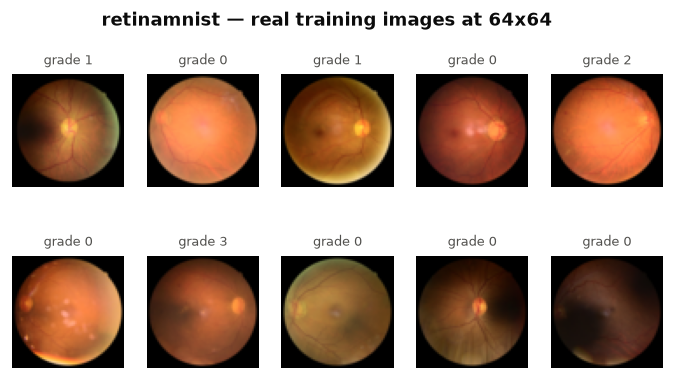

[saved] outputs/02_class_balance.png


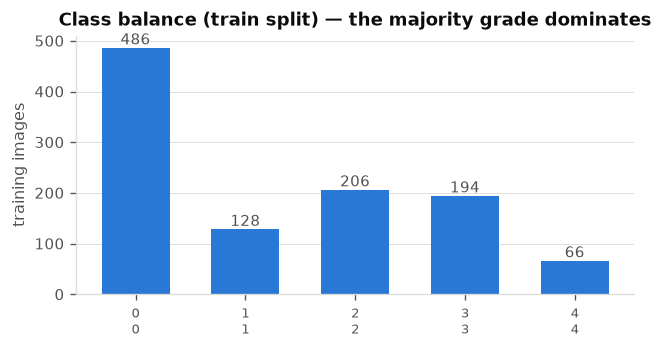

In [34]:
set_seed(CONFIG["seed"])
n_show = 10
fig, axes = plt.subplots(2, n_show // 2, figsize=(1.5 * n_show // 2, 3.6))
idx = np.random.RandomState(0).choice(len(EVAL_IMGS["train"]), n_show, replace=False)
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(EVAL_IMGS["train"][i].permute(1, 2, 0).numpy())
    ax.set_title(f"grade {EVAL_LABELS['train'][i]}", fontsize=8, color=INK2, fontweight="normal")
    ax.axis("off")
fig.suptitle(f"{DATA_FLAG} — real training images at {CONFIG['img_size']}x{CONFIG['img_size']}",
             fontsize=11, fontweight="bold", color=INK)
save_fig(fig, "01_dataset_samples.png")
plt.show()

# Class-balance bar chart: makes the imbalance impossible to forget.
fig, ax = plt.subplots(figsize=(6.0, 2.8))
counts = np.bincount(EVAL_LABELS["train"], minlength=NUM_CLASSES)
ax.bar(range(NUM_CLASSES), counts, color="#2a78d6", width=0.62)
for i, c in enumerate(counts):
    ax.text(i, c, f"{c}", ha="center", va="bottom", fontsize=9, color=INK2)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([f"{i}\n{n.split(' ')[0][:12]}" for i, n in enumerate(CLASS_LABELS)], fontsize=8)
ax.set_ylabel("training images")
ax.set_title("Class balance (train split) — the majority grade dominates")
style_axes(ax)
save_fig(fig, "02_class_balance.png")
plt.show()

---
## 3. The shared ViT backbone

This is the fairness guarantee of the whole notebook: **one encoder class, one config,
instantiated twice.** If MAE and JEPA differed in width, depth, or positional encoding,
any accuracy gap would be uninterpretable.

Design choices, and why:

- **No CLS token.** Features are a global average pool over patch tokens. MAE's encoder
  never sees masked positions and JEPA's context encoder sees only a subset, so a CLS
  token would be trained under different conditions in each method. Mean pooling is
  symmetric and is what both papers' linear probes effectively rely on anyway.
- **`forward` takes an optional `keep_idx`.** This one argument is what lets the *same*
  class serve as MAE's visible-patch encoder, JEPA's context encoder, JEPA's full-image
  teacher, and the frozen full-image feature extractor. Positional embeddings are added
  **before** subsetting, so a kept token always carries its true position — getting this
  backwards is a classic silent bug that turns the encoder permutation-invariant.
- **Pre-norm blocks, learnable positional embeddings, no dropout.** Standard ViT, kept
  minimal so the code is readable next to the paper.

In [35]:
class Attention(nn.Module):
    """Plain multi-head self-attention, written out rather than imported.

    Explicit matmul + softmax keeps every MPS op boring and well-supported.
    """

    def __init__(self, dim: int, num_heads: int):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(out)


class Block(nn.Module):
    """Pre-norm transformer block: x + attn(ln(x)), then x + mlp(ln(x))."""

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hidden), nn.GELU(), nn.Linear(hidden, dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class ViTEncoder(nn.Module):
    """The single backbone shared by MAE and I-JEPA.

    `forward(x, keep_idx)` serves every role we need:
      * keep_idx=None            -> full image (teacher / frozen feature extractor)
      * keep_idx=visible patches -> MAE encoder
      * keep_idx=context patches -> JEPA context encoder
    """

    def __init__(self, img_size, patch_size, in_chans, embed_dim, depth, num_heads, mlp_ratio):
        super().__init__()
        self.img_size, self.patch_size, self.in_chans = img_size, patch_size, in_chans
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size ** 2
        self.embed_dim = embed_dim

        # Patchify + linear project, done as a strided conv (the standard trick).
        self.patch_embed = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        # Learnable positional embedding, one per patch position.
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        self.blocks = nn.ModuleList([Block(embed_dim, num_heads, mlp_ratio) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.apply(self._init)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv2d):
            nn.init.xavier_uniform_(m.weight.view(m.weight.shape[0], -1).data)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def embed(self, x: torch.Tensor) -> torch.Tensor:
        """(B,C,H,W) -> (B,N,D) patch tokens WITH positional embeddings already added."""
        x = self.patch_embed(x.to(torch.float32))  # (B,D,g,g)
        x = x.flatten(2).transpose(1, 2)  # (B,N,D)
        return x + self.pos_embed

    def forward_tokens(self, tokens: torch.Tensor) -> torch.Tensor:
        for blk in self.blocks:
            tokens = blk(tokens)
        return self.norm(tokens)

    def forward(self, x: torch.Tensor, keep_idx: torch.Tensor | None = None) -> torch.Tensor:
        """keep_idx: LongTensor of patch indices to keep, shared across the batch."""
        tokens = self.embed(x)  # positions added BEFORE subsetting
        if keep_idx is not None:
            tokens = tokens[:, keep_idx, :]
        return self.forward_tokens(tokens)


def make_encoder() -> ViTEncoder:
    """Both methods call THIS. Same class, same config, no exceptions."""
    return ViTEncoder(
        img_size=CONFIG["img_size"],
        patch_size=CONFIG["patch_size"],
        in_chans=3,
        embed_dim=CONFIG["embed_dim"],
        depth=CONFIG["depth"],
        num_heads=CONFIG["num_heads"],
        mlp_ratio=CONFIG["mlp_ratio"],
    )


def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


_probe = make_encoder()
print(f"shared encoder : {count_params(_probe) / 1e6:.2f}M params, "
      f"dim={CONFIG['embed_dim']}, depth={CONFIG['depth']}, heads={CONFIG['num_heads']}, "
      f"{_probe.num_patches} patches")
with torch.no_grad():
    _o = _probe(torch.zeros(2, 3, CONFIG["img_size"], CONFIG["img_size"]))
print(f"shape check    : full image -> {tuple(_o.shape)}  (B, N, D)")
with torch.no_grad():
    _o = _probe(torch.zeros(2, 3, CONFIG["img_size"], CONFIG["img_size"]),
                keep_idx=torch.arange(10))
print(f"shape check    : keep_idx=10 -> {tuple(_o.shape)}  (subsetting works)")
del _probe, _o

shared encoder : 2.72M params, dim=192, depth=6, heads=3, 64 patches
shape check    : full image -> (2, 64, 192)  (B, N, D)
shape check    : keep_idx=10 -> (2, 10, 192)  (subsetting works)


### Shared optimization utilities

Both training loops call the same two helpers, which is the other half of the fairness
guarantee. Two details that matter more than they look:

- **Weight decay excludes biases, LayerNorm parameters, positional embeddings, and mask
  tokens.** Decaying a positional embedding toward zero actively destroys information.
- **Cosine schedule with linear warmup.** Warmup matters here because both objectives
  start from a random encoder and a random head; without it the first steps take large,
  badly-directed strides.

[saved] outputs/03_lr_schedule.png


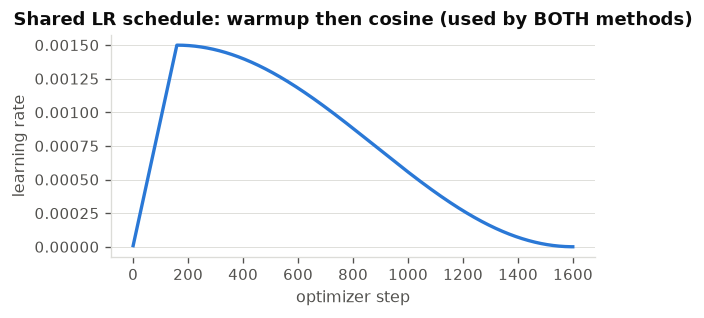

In [36]:
def param_groups(*modules: nn.Module, weight_decay: float):
    """AdamW groups: decay 2-D+ weights only; never decay norms, biases, or embeddings."""
    decay, no_decay = [], []
    for mod in modules:
        for name, p in mod.named_parameters():
            if not p.requires_grad:
                continue
            if p.ndim <= 1 or name.endswith("pos_embed") or "token" in name:
                no_decay.append(p)
            else:
                decay.append(p)
    return [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]


def lr_at_step(step: int) -> float:
    """Linear warmup then cosine decay to min_lr. Identical for both methods."""
    warmup_steps = CONFIG["warmup_epochs"] * STEPS_PER_EPOCH
    base, floor = CONFIG["lr"], CONFIG["min_lr"]
    if step < warmup_steps:
        return base * (step + 1) / max(1, warmup_steps)
    prog = (step - warmup_steps) / max(1, TOTAL_STEPS - warmup_steps)
    return floor + (base - floor) * 0.5 * (1.0 + math.cos(math.pi * min(1.0, prog)))


def set_lr(optimizer, lr: float) -> None:
    for g in optimizer.param_groups:
        g["lr"] = lr


fig, ax = plt.subplots(figsize=(5.2, 2.4))
ax.plot([lr_at_step(s) for s in range(TOTAL_STEPS)], color="#2a78d6")
ax.set_xlabel("optimizer step")
ax.set_ylabel("learning rate")
ax.set_title("Shared LR schedule: warmup then cosine (used by BOTH methods)")
style_axes(ax)
save_fig(fig, "03_lr_schedule.png")
plt.show()

---
## 4. MAE — Masked Autoencoder

> **The one key idea: hide most of the image, then redraw the missing pixels.**

The encoder is shown only the ~25% of patches that survive random masking — it never
sees a mask token, which is what makes MAE cheap to train. A small decoder then receives
the encoded visible tokens *plus* a shared learnable mask token at every hidden
position, and outputs raw pixel values. The loss is mean-squared error on the masked
patches only; predicting the patches you were shown is free and would teach nothing.

The decoder is deliberately **shallow and narrow** (depth 3, dim 96 here). That
asymmetry is the mechanism: the decoder is a task-specific tool that gets discarded
after pretraining, so making it weak forces the *encoder* to carry the semantics. If the
decoder were as large as the encoder, it could reconstruct competently from mediocre
features and the encoder would learn less.

**What MAE optimizes is a pixel objective.** Nothing in the loss distinguishes a pixel
that carries a lesion from a pixel that carries sensor noise — both contribute squared
error in proportion to their magnitude. Hold on to that thought; section 8 tests exactly
this.

One knob, `mae_norm_pix_loss`: with it on, targets are each patch's pixels standardized
by that patch's own mean and variance. The paper found this improves representations
(it stops the loss from being dominated by low-frequency brightness), and we default it
off only so section 7's pictures are honest without post-hoc rescaling.

In [37]:
class MAE(nn.Module):
    """Masked Autoencoder with a pixel-reconstruction decoder."""

    def __init__(self, encoder: ViTEncoder, decoder_dim: int, decoder_depth: int,
                 decoder_heads: int, norm_pix_loss: bool):
        super().__init__()
        self.encoder = encoder
        self.norm_pix_loss = norm_pix_loss
        p, c = encoder.patch_size, encoder.in_chans
        self.patch_dim = p * p * c

        # --- decoder: narrow + shallow on purpose --------------------------
        self.decoder_embed = nn.Linear(encoder.embed_dim, decoder_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, encoder.num_patches, decoder_dim))
        self.decoder_blocks = nn.ModuleList(
            [Block(decoder_dim, decoder_heads, CONFIG["mlp_ratio"]) for _ in range(decoder_depth)]
        )
        self.decoder_norm = nn.LayerNorm(decoder_dim)
        self.decoder_pred = nn.Linear(decoder_dim, self.patch_dim, bias=True)

        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

    # ---- pixel <-> patch plumbing ----------------------------------------
    def patchify(self, imgs: torch.Tensor) -> torch.Tensor:
        """(B,C,H,W) -> (B,N,p*p*C)."""
        p, c = self.encoder.patch_size, self.encoder.in_chans
        B, _, H, W = imgs.shape
        g = H // p
        x = imgs.reshape(B, c, g, p, g, p).permute(0, 2, 4, 3, 5, 1)  # B,g,g,p,p,C
        return x.reshape(B, g * g, p * p * c)

    def unpatchify(self, x: torch.Tensor) -> torch.Tensor:
        """(B,N,p*p*C) -> (B,C,H,W). Exact inverse of patchify."""
        p, c = self.encoder.patch_size, self.encoder.in_chans
        g = self.encoder.grid_size
        B = x.shape[0]
        x = x.reshape(B, g, g, p, p, c).permute(0, 5, 1, 3, 2, 4)
        return x.reshape(B, c, g * p, g * p)

    # ---- masking ---------------------------------------------------------
    @staticmethod
    def random_masking(x: torch.Tensor, mask_ratio: float, generator=None):
        """Per-sample random masking by sort-of-noise (the trick from the MAE code).

        Returns kept tokens, a binary mask (1 = masked), and the indices that restore
        the original patch order.
        """
        B, N, D = x.shape
        len_keep = max(1, int(round(N * (1 - mask_ratio))))
        # Noise is drawn on CPU and moved: MPS generators are finicky, and B*N is tiny.
        noise = torch.rand(B, N, generator=generator).to(x.device)
        ids_shuffle = torch.argsort(noise, dim=1)  # low noise -> keep
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
        x_kept = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))
        mask = torch.ones(B, N, device=x.device, dtype=x.dtype)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)  # 1 = removed, in original order
        return x_kept, mask, ids_restore

    # ---- forward ---------------------------------------------------------
    def forward_encoder(self, imgs: torch.Tensor, mask_ratio: float, generator=None):
        tokens = self.encoder.embed(imgs)  # (B,N,D), positions already added
        kept, mask, ids_restore = self.random_masking(tokens, mask_ratio, generator)
        latent = self.encoder.forward_tokens(kept)  # encoder sees VISIBLE patches only
        return latent, mask, ids_restore

    def forward_decoder(self, latent: torch.Tensor, ids_restore: torch.Tensor) -> torch.Tensor:
        x = self.decoder_embed(latent)
        B, N = ids_restore.shape
        n_mask = N - x.shape[1]
        mask_tokens = self.mask_token.expand(B, n_mask, -1)
        x = torch.cat([x, mask_tokens], dim=1)
        # Put every token back at its original position, then add decoder positions.
        x = torch.gather(x, 1, ids_restore.unsqueeze(-1).expand(-1, -1, x.shape[2]))
        x = x + self.decoder_pos_embed
        for blk in self.decoder_blocks:
            x = blk(x)
        return self.decoder_pred(self.decoder_norm(x))  # (B,N,patch_dim)

    def targets(self, imgs: torch.Tensor):
        """Pixel targets, optionally per-patch standardized (MAE paper's norm_pix_loss)."""
        tgt = self.patchify(imgs)
        if self.norm_pix_loss:
            mu = tgt.mean(dim=-1, keepdim=True)
            var = tgt.var(dim=-1, keepdim=True)
            tgt = (tgt - mu) / (var + 1e-6).sqrt()
            return tgt, mu, var
        return tgt, None, None

    def forward(self, imgs: torch.Tensor, mask_ratio: float | None = None, generator=None):
        mask_ratio = CONFIG["mae_mask_ratio"] if mask_ratio is None else mask_ratio
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio, generator)
        pred = self.forward_decoder(latent, ids_restore)
        tgt, _, _ = self.targets(imgs)
        # MSE per patch, then averaged over MASKED patches only.
        per_patch = (pred - tgt).pow(2).mean(dim=-1)
        loss = (per_patch * mask).sum() / mask.sum().clamp_min(1.0)
        return loss, pred, mask


set_seed(CONFIG["seed"])
_m = MAE(make_encoder(), CONFIG["mae_decoder_dim"], CONFIG["mae_decoder_depth"],
         CONFIG["mae_decoder_heads"], CONFIG["mae_norm_pix_loss"])
print(f"MAE encoder    : {count_params(_m.encoder) / 1e6:.2f}M params")
print(f"MAE decoder    : {(count_params(_m) - count_params(_m.encoder)) / 1e6:.2f}M params "
      f"(dim={CONFIG['mae_decoder_dim']}, depth={CONFIG['mae_decoder_depth']}) <- deliberately small")
# Sanity: patchify/unpatchify must round-trip exactly.
_x = torch.randn(2, 3, CONFIG["img_size"], CONFIG["img_size"])
assert torch.allclose(_m.unpatchify(_m.patchify(_x)), _x, atol=1e-6), "patchify round-trip broken"
print("shape check    : patchify/unpatchify round-trip exact")
del _m, _x

MAE encoder    : 2.72M params
MAE decoder    : 0.38M params (dim=96, depth=3) <- deliberately small
shape check    : patchify/unpatchify round-trip exact


### Train MAE

In [38]:
def train_mae():
    set_seed(CONFIG["seed"])  # same seed as JEPA: identical encoder init
    model = MAE(
        make_encoder(),
        CONFIG["mae_decoder_dim"],
        CONFIG["mae_decoder_depth"],
        CONFIG["mae_decoder_heads"],
        CONFIG["mae_norm_pix_loss"],
    ).to(DEVICE)
    opt = torch.optim.AdamW(
        param_groups(model, weight_decay=CONFIG["weight_decay"]),
        lr=CONFIG["lr"],
        betas=(0.9, 0.95),
    )
    history = {"epoch_loss": [], "lr": []}
    step = 0
    pbar = tqdm(range(CONFIG["epochs"]), desc="MAE pretrain", leave=True)
    for epoch in pbar:
        model.train()
        running, nb = 0.0, 0
        for imgs, _ in pretrain_loader:  # labels deliberately discarded
            imgs = imgs.to(DEVICE, dtype=torch.float32, non_blocking=False)
            lr = lr_at_step(step)
            set_lr(opt, lr)
            loss, _, _ = model(imgs)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 3.0)
            opt.step()
            running += float(loss.detach())
            nb += 1
            step += 1
        history["epoch_loss"].append(running / max(1, nb))
        history["lr"].append(lr)
        pbar.set_postfix(loss=f"{history['epoch_loss'][-1]:.4f}", lr=f"{lr:.2e}")
    return model, history


with Phase("4. MAE pretraining"):
    mae_model, mae_hist = train_mae()

print(f"first-epoch loss {mae_hist['epoch_loss'][0]:.4f}  ->  final {mae_hist['epoch_loss'][-1]:.4f}")


=== 4. MAE pretraining ===


MAE pretrain:   0%|          | 0/100 [00:00<?, ?it/s]

=== 4. MAE pretraining: 66.7s wall-clock (1.11 min) ===
first-epoch loss 1.0391  ->  final 0.0804


[saved] outputs/04_mae_loss.png


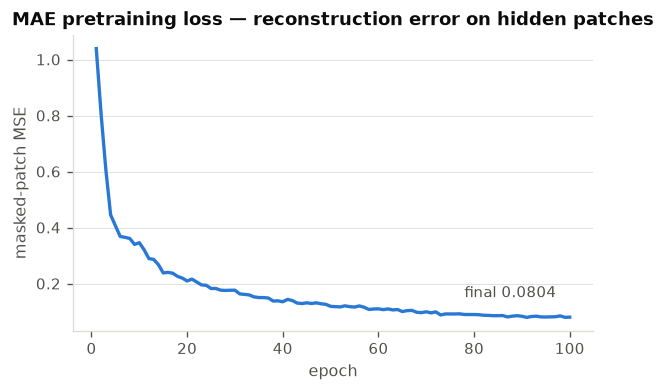

In [39]:
fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.plot(range(1, len(mae_hist["epoch_loss"]) + 1), mae_hist["epoch_loss"], color=COLORS["MAE"])
ax.set_xlabel("epoch")
ax.set_ylabel("masked-patch MSE" + (" (norm. pixels)" if CONFIG["mae_norm_pix_loss"] else ""))
ax.set_title("MAE pretraining loss — reconstruction error on hidden patches")
ax.annotate(f"final {mae_hist['epoch_loss'][-1]:.4f}",
            xy=(len(mae_hist["epoch_loss"]), mae_hist["epoch_loss"][-1]),
            xytext=(-8, 12), textcoords="offset points", ha="right", fontsize=9, color=INK2)
style_axes(ax)
save_fig(fig, "04_mae_loss.png")
plt.show()

---
## 5. I-JEPA — Joint-Embedding Predictive Architecture

> **The one key idea: hide a few blocks, then predict what a slow teacher network would
> *think* about them — never what they look like.**

Three parts, and the interaction between them is where the subtlety lives:

1. **Context encoder** — the network we actually keep. Sees one large block of patches
   with the target regions cut out.
2. **Target encoder (EMA teacher)** — a copy of the context encoder whose weights are an
   exponential moving average of it, updated *after* every optimizer step. It sees the
   **full** image. **No gradient ever flows into it**: its outputs go through
   `torch.no_grad()` and act as a fixed target within the step.
3. **Predictor** — a narrow transformer that takes the context tokens plus one learnable
   **mask token per target position** (each stamped with that position's positional
   embedding) and outputs a predicted latent vector for each target patch.

The loss is a **SmoothL1 (Huber)** distance in latent space, averaged over target
blocks. **No pixels appear anywhere in it.**

**Why this doesn't collapse.** A latent-target objective has a trivial solution: output
the same constant everywhere, and the prediction is perfect. Two things block it. The
**stop-gradient** means the encoder can't reshape the target to be easier to hit — it
can only move toward the target. And the **EMA** makes the teacher a lagged average of
past students: to collapse, the student would have to outrun its own history, and the
momentum (0.996, cosine-scheduled toward 1.0) makes the teacher move too slowly for that
to be stable. This is not a footnote — it is the load-bearing design decision, and we
monitor it directly during training below.

**Why contiguous blocks, not scattered patches.** MAE's scattered 75% masking leaves a
visible neighbor next to almost every hidden patch, so low-level interpolation goes a
long way. Masking whole blocks removes that shortcut: to say anything about a 3x4 region
you never saw, you have to reason about *what kind of region it is*.

In [40]:
def sample_block(grid: int, scale: tuple, ar_range: tuple, rng: np.random.RandomState):
    """Sample one rectangular block of patches. Returns a (grid,grid) boolean mask."""
    n = grid * grid
    for _ in range(20):
        area = rng.uniform(*scale) * n
        ar = math.exp(rng.uniform(math.log(ar_range[0]), math.log(ar_range[1])))
        h = int(round(math.sqrt(area / ar)))
        w = int(round(math.sqrt(area * ar)))
        h, w = min(max(h, 1), grid), min(max(w, 1), grid)
        top = rng.randint(0, grid - h + 1)
        left = rng.randint(0, grid - w + 1)
        m = np.zeros((grid, grid), dtype=bool)
        m[top:top + h, left:left + w] = True
        if m.any():
            return m
    m = np.zeros((grid, grid), dtype=bool)
    m[0, 0] = True
    return m


def multiblock_mask(grid: int, rng: np.random.RandomState):
    """I-JEPA multi-block masking, sampled ONCE PER BATCH (as the official collator does).

    Returns (context_idx, [target_idx, ...]) as flat patch-index arrays.
    Target regions are REMOVED from the context — that's what makes the task predictive
    rather than a lookup.
    """
    for _ in range(50):
        targets = [
            sample_block(grid, CONFIG["jepa_target_scale"], CONFIG["jepa_target_ar"], rng)
            for _ in range(CONFIG["jepa_num_targets"])
        ]
        union = np.zeros((grid, grid), dtype=bool)
        for t in targets:
            union |= t
        ctx_block = sample_block(grid, CONFIG["jepa_context_scale"], (1.0, 1.0), rng)
        ctx = ctx_block & ~union  # <-- remove the targets from the context
        if ctx.sum() >= 4:  # need a usable context
            ctx_idx = np.flatnonzero(ctx.reshape(-1))
            tgt_idx = [np.flatnonzero(t.reshape(-1)) for t in targets]
            return ctx_idx, tgt_idx
    # Degenerate fallback (shouldn't trigger at default settings).
    all_idx = np.arange(grid * grid)
    return all_idx[: grid], [all_idx[grid: 2 * grid]]


_rng = np.random.RandomState(CONFIG["seed"])
_c, _t = multiblock_mask(GRID_SIZE, _rng)
print(f"context patches: {len(_c)} / {NUM_PATCHES}")
print(f"target blocks  : {[len(t) for t in _t]} patches each "
      f"(union {len(set(np.concatenate(_t).tolist()))} unique)")
print(f"overlap check  : context ∩ targets = {len(set(_c) & set(np.concatenate(_t).tolist()))} "
      f"(must be 0)")

context patches: 24 / 64
target blocks  : [12, 9, 12, 12] patches each (union 40 unique)
overlap check  : context ∩ targets = 0 (must be 0)


### What the masking looks like

Worth seeing once. Blue-tinted = the context the encoder gets. Orange = the target
blocks it must predict (in latent space). Gray = seen by neither, because the context
block itself doesn't always cover the whole grid.

[saved] outputs/05_jepa_masking.png


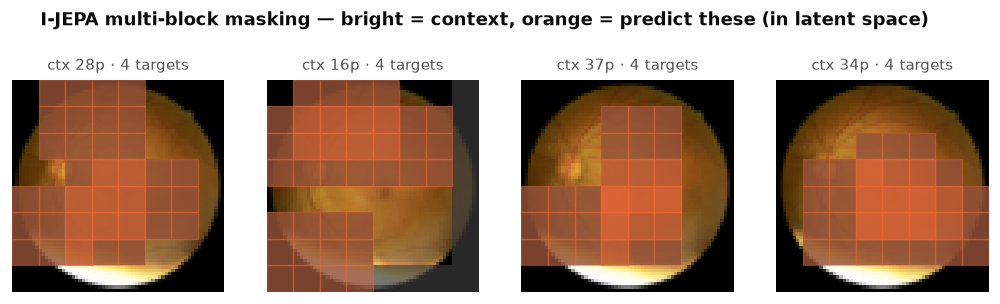

In [41]:
set_seed(CONFIG["seed"])
rng_viz = np.random.RandomState(7)
fig, axes = plt.subplots(1, 4, figsize=(10.5, 3.0))
img = EVAL_IMGS["test"][3].permute(1, 2, 0).numpy()
ps = CONFIG["patch_size"]
for ax in axes:
    c_idx, t_idxs = multiblock_mask(GRID_SIZE, rng_viz)
    canvas = img.copy() * 0.30 + 0.16  # everything starts dim (= unseen)
    for i in c_idx:  # context: full brightness
        r, cc = divmod(int(i), GRID_SIZE)
        canvas[r * ps:(r + 1) * ps, cc * ps:(cc + 1) * ps] = img[r * ps:(r + 1) * ps, cc * ps:(cc + 1) * ps]
    ax.imshow(np.clip(canvas, 0, 1))
    for t in t_idxs:  # targets: orange outline
        for i in t:
            r, cc = divmod(int(i), GRID_SIZE)
            ax.add_patch(plt.Rectangle((cc * ps - 0.5, r * ps - 0.5), ps, ps,
                                       facecolor=COLORS["I-JEPA"], alpha=0.42,
                                       edgecolor=COLORS["I-JEPA"], linewidth=0.8))
    ax.set_title(f"ctx {len(c_idx)}p · {len(t_idxs)} targets", fontsize=9, fontweight="normal",
                 color=INK2)
    ax.axis("off")
fig.suptitle("I-JEPA multi-block masking — bright = context, orange = predict these (in latent space)",
             fontsize=11, fontweight="bold", color=INK)
save_fig(fig, "05_jepa_masking.png")
plt.show()

In [42]:
class Predictor(nn.Module):
    """Narrow transformer that maps context latents -> latents at target positions.

    The bottleneck (pred_dim << embed_dim) is intentional: a predictor strong enough to
    model the teacher's output in detail would let the encoder off the hook.
    """

    def __init__(self, embed_dim: int, pred_dim: int, depth: int, num_heads: int, num_patches: int):
        super().__init__()
        self.embed = nn.Linear(embed_dim, pred_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, pred_dim))
        # The predictor keeps its OWN positional embeddings: this is how a mask token
        # knows *which* target patch it is asking about.
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, pred_dim))
        self.blocks = nn.ModuleList([Block(pred_dim, num_heads, CONFIG["mlp_ratio"])
                                     for _ in range(depth)])
        self.norm = nn.LayerNorm(pred_dim)
        self.out = nn.Linear(pred_dim, embed_dim, bias=True)
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, z_ctx: torch.Tensor, ctx_idx: torch.Tensor, tgt_idx: torch.Tensor):
        B = z_ctx.shape[0]
        x = self.embed(z_ctx) + self.pos_embed[:, ctx_idx, :]
        q = self.mask_token.expand(B, tgt_idx.numel(), -1) + self.pos_embed[:, tgt_idx, :]
        h = torch.cat([x, q], dim=1)
        for blk in self.blocks:
            h = blk(h)
        h = self.norm(h[:, x.shape[1]:, :])  # keep only the mask-token outputs
        return self.out(h)


class IJEPA(nn.Module):
    """Context encoder + EMA target encoder + narrow predictor."""

    def __init__(self, encoder: ViTEncoder, pred_dim, pred_depth, pred_heads):
        super().__init__()
        self.context_encoder = encoder
        self.predictor = Predictor(encoder.embed_dim, pred_dim, pred_depth, pred_heads,
                                   encoder.num_patches)
        # --- the EMA teacher: a copy, frozen to autograd -------------------
        self.target_encoder = copy.deepcopy(encoder)
        for p in self.target_encoder.parameters():
            p.requires_grad = False  # NO gradients, ever

    @torch.no_grad()
    def ema_update(self, momentum: float) -> None:
        """target <- m * target + (1-m) * context. Called AFTER each optimizer step."""
        for pt, pc in zip(self.target_encoder.parameters(), self.context_encoder.parameters()):
            pt.data.mul_(momentum).add_(pc.detach().data, alpha=1.0 - momentum)
        for bt, bc in zip(self.target_encoder.buffers(), self.context_encoder.buffers()):
            bt.data.copy_(bc.data)

    def forward(self, imgs: torch.Tensor, ctx_idx: torch.Tensor, tgt_idxs: list):
        # 1) context encoder on the visible context block only
        z_ctx = self.context_encoder(imgs, keep_idx=ctx_idx)

        # 2) teacher on the FULL image, under no_grad (stop-gradient)
        with torch.no_grad():
            h_full = self.target_encoder(imgs)
            # I-JEPA applies LayerNorm to the targets: it puts the regression on a
            # consistent scale and is part of what keeps training stable.
            h_full = F.layer_norm(h_full, (h_full.shape[-1],))
        target_std = float(h_full.std(dim=0).mean())  # collapse monitor (see below)

        # 3) predictor: one forward per target block, as in the paper
        loss = imgs.new_zeros(())
        for tgt in tgt_idxs:
            pred = self.predictor(z_ctx, ctx_idx, tgt)
            # Huber in LATENT space. No pixels anywhere.
            loss = loss + F.smooth_l1_loss(pred, h_full[:, tgt, :].detach())
        loss = loss / max(1, len(tgt_idxs))
        return loss, target_std


set_seed(CONFIG["seed"])
_j = IJEPA(make_encoder(), CONFIG["jepa_pred_dim"], CONFIG["jepa_pred_depth"],
           CONFIG["jepa_pred_heads"])
print(f"JEPA context enc: {count_params(_j.context_encoder) / 1e6:.2f}M params (this is what we keep)")
print(f"JEPA predictor  : {count_params(_j.predictor) / 1e6:.2f}M params "
      f"(dim={CONFIG['jepa_pred_dim']}, depth={CONFIG['jepa_pred_depth']}) <- narrow on purpose")
print(f"JEPA teacher    : {sum(p.numel() for p in _j.target_encoder.parameters())/1e6:.2f}M params, "
      f"requires_grad={any(p.requires_grad for p in _j.target_encoder.parameters())} <- must be False")
_teacher_at_init = torch.allclose(
    next(_j.target_encoder.parameters()), next(_j.context_encoder.parameters()))
print(f"teacher == student at init: {_teacher_at_init} (EMA starts as an exact copy)")
del _j

JEPA context enc: 2.72M params (this is what we keep)
JEPA predictor  : 0.38M params (dim=96, depth=3) <- narrow on purpose
JEPA teacher    : 2.72M params, requires_grad=False <- must be False
teacher == student at init: True (EMA starts as an exact copy)


### Train I-JEPA

Alongside the loss we log **`target_std`**: the standard deviation of the teacher's
features across the batch, averaged over dimensions. This is the collapse detector. If
the model were taking the degenerate shortcut — same output for every image — this number
would slide toward zero while the loss also fell. Loss going down *and* `target_std`
staying up is the signal that the representation is still doing work. Watch both.

In [43]:
def ema_momentum_at(step: int) -> float:
    """0.996 -> 1.0 on a cosine, if enabled. A teacher that slows to a stop late in
    training gives an increasingly stable target."""
    base = CONFIG["jepa_ema"]
    if not CONFIG["jepa_ema_cosine"]:
        return base
    prog = step / max(1, TOTAL_STEPS - 1)
    return 1.0 - (1.0 - base) * 0.5 * (1.0 + math.cos(math.pi * prog))


def train_jepa():
    set_seed(CONFIG["seed"])  # same seed as MAE: identical encoder init
    model = IJEPA(
        make_encoder(),
        CONFIG["jepa_pred_dim"],
        CONFIG["jepa_pred_depth"],
        CONFIG["jepa_pred_heads"],
    ).to(DEVICE)
    # Only the context encoder and predictor are optimized. The teacher moves by EMA only.
    opt = torch.optim.AdamW(
        param_groups(model.context_encoder, model.predictor, weight_decay=CONFIG["weight_decay"]),
        lr=CONFIG["lr"],
        betas=(0.9, 0.95),
    )
    mask_rng = np.random.RandomState(CONFIG["seed"] + 1)
    history = {"epoch_loss": [], "target_std": [], "momentum": [], "ctx_frac": []}
    step = 0
    pbar = tqdm(range(CONFIG["epochs"]), desc="I-JEPA pretrain", leave=True)
    for epoch in pbar:
        model.train()
        run_loss, run_std, run_ctx, nb = 0.0, 0.0, 0.0, 0
        for imgs, _ in pretrain_loader:  # labels deliberately discarded
            imgs = imgs.to(DEVICE, dtype=torch.float32, non_blocking=False)
            # One mask sample per batch, shared across the batch (official collator behavior).
            ctx_np, tgt_np = multiblock_mask(GRID_SIZE, mask_rng)
            ctx_idx = torch.from_numpy(ctx_np).long().to(DEVICE)
            tgt_idxs = [torch.from_numpy(t).long().to(DEVICE) for t in tgt_np]

            set_lr(opt, lr_at_step(step))
            loss, tstd = model(imgs, ctx_idx, tgt_idxs)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(model.context_encoder.parameters()) + list(model.predictor.parameters()), 3.0)
            opt.step()
            # EMA update AFTER the optimizer step.
            model.ema_update(ema_momentum_at(step))

            run_loss += float(loss.detach())
            run_std += tstd
            run_ctx += len(ctx_np) / NUM_PATCHES
            nb += 1
            step += 1
        history["epoch_loss"].append(run_loss / max(1, nb))
        history["target_std"].append(run_std / max(1, nb))
        history["ctx_frac"].append(run_ctx / max(1, nb))
        history["momentum"].append(ema_momentum_at(step - 1))
        pbar.set_postfix(loss=f"{history['epoch_loss'][-1]:.4f}",
                         tgt_std=f"{history['target_std'][-1]:.3f}")
    return model, history


with Phase("5. I-JEPA pretraining"):
    jepa_model, jepa_hist = train_jepa()

print(f"first-epoch loss {jepa_hist['epoch_loss'][0]:.4f}  ->  final {jepa_hist['epoch_loss'][-1]:.4f}")
print(f"teacher feature std {jepa_hist['target_std'][0]:.3f}  ->  {jepa_hist['target_std'][-1]:.3f}"
      "   (staying well above 0 = no collapse)")
print(f"mean context fraction: {np.mean(jepa_hist['ctx_frac']):.2f} of patches visible")
print(f"EMA momentum {jepa_hist['momentum'][0]:.4f} -> {jepa_hist['momentum'][-1]:.4f}")


=== 5. I-JEPA pretraining ===


I-JEPA pretrain:   0%|          | 0/100 [00:00<?, ?it/s]

=== 5. I-JEPA pretraining: 151.2s wall-clock (2.52 min) ===
first-epoch loss 0.4128  ->  final 0.0873
teacher feature std 0.777  ->  0.678   (staying well above 0 = no collapse)
mean context fraction: 0.48 of patches visible
EMA momentum 0.9960 -> 1.0000


The two curves below are deliberately **not** on the same axes as MAE's. MAE's loss is a
pixel MSE; JEPA's is a Huber distance between latent vectors. They have different units
and different scales, and putting them on one plot with two y-axes would invite a
comparison that has no meaning. Loss values are only comparable *within* a method.

[saved] outputs/06_jepa_loss_and_collapse.png


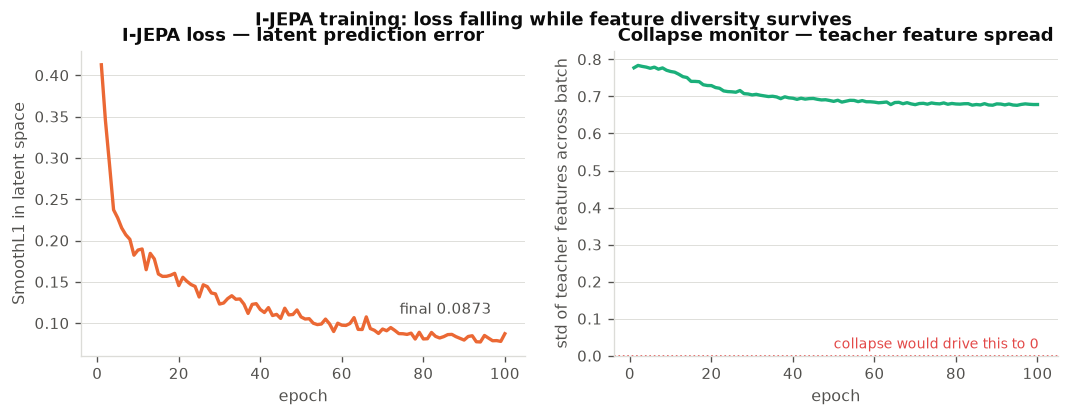

[saved] outputs/07_both_loss_curves.png


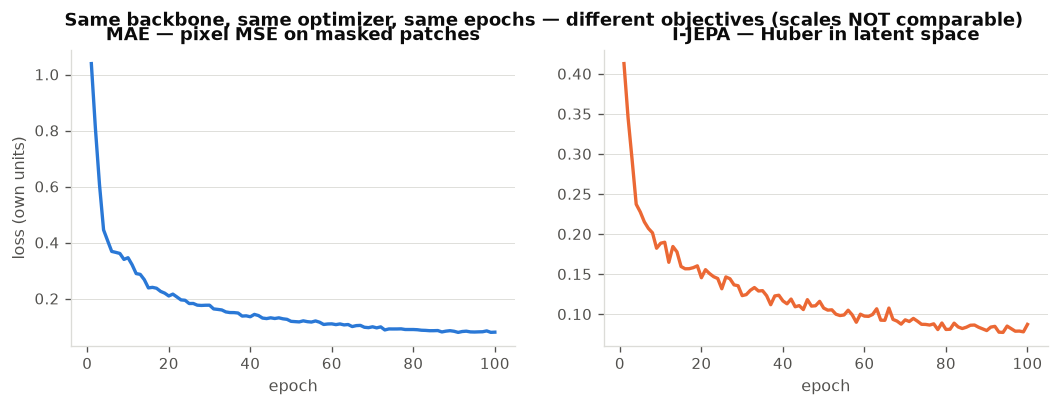

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.3))
ep = range(1, len(jepa_hist["epoch_loss"]) + 1)

ax = axes[0]
ax.plot(ep, jepa_hist["epoch_loss"], color=COLORS["I-JEPA"])
ax.set_xlabel("epoch")
ax.set_ylabel("SmoothL1 in latent space")
ax.set_title("I-JEPA loss — latent prediction error")
ax.annotate(f"final {jepa_hist['epoch_loss'][-1]:.4f}",
            xy=(len(jepa_hist["epoch_loss"]), jepa_hist["epoch_loss"][-1]),
            xytext=(-8, 12), textcoords="offset points", ha="right", fontsize=9, color=INK2)
style_axes(ax)

ax = axes[1]
ax.plot(ep, jepa_hist["target_std"], color=COLORS["I-JEPA (EMA teacher)"])
ax.axhline(0, color="#e34948", linewidth=1.0, linestyle=":")
ax.text(len(ep) * 0.5, 0.02, "collapse would drive this to 0", fontsize=8.5, color="#e34948")
ax.set_xlabel("epoch")
ax.set_ylabel("std of teacher features across batch")
ax.set_ylim(bottom=0)
ax.set_title("Collapse monitor — teacher feature spread")
style_axes(ax)

fig.suptitle("I-JEPA training: loss falling while feature diversity survives",
             fontsize=11, fontweight="bold", color=INK)
save_fig(fig, "06_jepa_loss_and_collapse.png")
plt.show()

# Both loss curves side by side, as separate panels with their own scales.
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2), sharex=True)
axes[0].plot(range(1, len(mae_hist["epoch_loss"]) + 1), mae_hist["epoch_loss"], color=COLORS["MAE"])
axes[0].set_title("MAE — pixel MSE on masked patches")
axes[1].plot(ep, jepa_hist["epoch_loss"], color=COLORS["I-JEPA"])
axes[1].set_title("I-JEPA — Huber in latent space")
for ax in axes:
    ax.set_xlabel("epoch")
    style_axes(ax)
axes[0].set_ylabel("loss (own units)")
fig.suptitle("Same backbone, same optimizer, same epochs — different objectives (scales NOT comparable)",
             fontsize=10.5, fontweight="bold", color=INK)
save_fig(fig, "07_both_loss_curves.png")
plt.show()

---
## 6. Frozen-feature evaluation — linear probe and kNN

From here on **no encoder is ever updated again.** We freeze each one, push **full,
unmasked** images through it, mean-pool the patch tokens, and ask how much class
information is sitting in that vector.

Four encoders go into the comparison:

| Row | What it is |
|---|---|
| **MAE** | the MAE encoder |
| **I-JEPA** | the JEPA **context** encoder — the one the method keeps |
| **I-JEPA (EMA teacher)** | the teacher; a temporal average of the student, often slightly smoother |
| **Random init** | the **same architecture, untrained**. The control. |

That last row is the most important number in the notebook. A randomly-initialized ViT
is not a blank slate — random projections of image patches already carry real signal, and
on a 1,000-image dataset they carry more than people expect. **Any pretraining that
doesn't clear the random-init row hasn't demonstrated that it learned anything.**

Two probes, because they fail differently:

- **Linear probe** (multinomial logistic regression, features standardized): asks whether
  the classes are *linearly separable*. More expressive, but on ~1,000 examples with
  192 dimensions it can overfit, and its result depends on regularization.
- **kNN** (k=20, cosine): asks whether *similar images land near each other*. No
  parameters to fit, far more stable on tiny data. **On a dataset this size, trust the
  kNN column more.**

We report plain accuracy *and* balanced accuracy (mean per-class recall), because the
class imbalance makes plain accuracy easy to game.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def add_noise(x: torch.Tensor, kind: str, sigma: float, seed: int) -> torch.Tensor:
    """Noise injected in PIXEL space ([0,1]) *before* normalization, so sigma is
    interpretable as a fraction of the dynamic range."""
    if sigma <= 0 or kind == "none":
        return x
    g = torch.Generator().manual_seed(seed)  # fixed: every method sees identical noise
    n = torch.randn(x.shape, generator=g, dtype=torch.float32)
    if kind == "gaussian":
        out = x + sigma * n
    elif kind == "speckle":  # multiplicative — closer to ultrasound/OCT speckle
        out = x + x * sigma * n
    else:
        raise ValueError(kind)
    return out.clamp_(0.0, 1.0)


@torch.no_grad()
def extract_features(encoder: nn.Module, imgs01: torch.Tensor, kind: str = "none",
                     sigma: float = 0.0) -> np.ndarray:
    """Frozen encoder -> mean-pooled token features for FULL, unmasked images."""
    encoder.eval()
    feats = []
    bs = CONFIG["eval_batch_size"]
    for i in range(0, imgs01.shape[0], bs):
        x = add_noise(imgs01[i:i + bs].clone(), kind, sigma, CONFIG["noise_seed"] + i)
        x = ((x - MEAN_T) / STD_T).to(DEVICE, dtype=torch.float32)  # float32: MPS rule 1
        tokens = encoder(x)  # (B,N,D), no keep_idx -> full image
        feats.append(tokens.mean(dim=1).float().cpu())
    return torch.cat(feats).numpy().astype(np.float32)


def l2norm(a: np.ndarray) -> np.ndarray:
    return a / np.clip(np.linalg.norm(a, axis=1, keepdims=True), 1e-8, None)


def linear_probe(ftr, ytr, fte, yte):
    """Standardize on TRAIN stats, fit multinomial logistic regression, score on TEST."""
    if len(np.unique(ytr)) < 2:
        return {"acc": float("nan"), "bacc": float("nan")}
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=1.0))
    clf.fit(ftr, ytr)
    p = clf.predict(fte)
    return {"acc": accuracy_score(yte, p), "bacc": balanced_accuracy_score(yte, p)}


def knn_probe(ftr, ytr, fte, yte, k=None):
    """Cosine kNN on L2-normalized features. k shrinks if the train set is tiny."""
    k = CONFIG["knn_k"] if k is None else k
    k = max(1, min(k, len(ytr)))
    if len(np.unique(ytr)) < 2:
        return {"acc": float("nan"), "bacc": float("nan")}
    knn = KNeighborsClassifier(n_neighbors=k, metric=CONFIG["knn_metric"], weights="distance")
    knn.fit(l2norm(ftr), ytr)
    p = knn.predict(l2norm(fte))
    return {"acc": accuracy_score(yte, p), "bacc": balanced_accuracy_score(yte, p)}


# ---- the four frozen encoders --------------------------------------------
set_seed(CONFIG["seed"])
random_encoder = make_encoder().to(DEVICE).eval()  # untrained control, same architecture

ENCODERS = {
    "MAE": mae_model.encoder.eval(),
    "I-JEPA": jepa_model.context_encoder.eval(),
    "I-JEPA (EMA teacher)": jepa_model.target_encoder.eval(),
    "Random init": random_encoder,
}
for enc in ENCODERS.values():
    for p in enc.parameters():
        p.requires_grad = False  # frozen, and provably so

y_train, y_test = EVAL_LABELS["train"], EVAL_LABELS["test"]

with Phase("6. feature extraction (clean)"):
    CLEAN = {
        name: {
            "train": extract_features(enc, EVAL_IMGS["train"]),
            "test": extract_features(enc, EVAL_IMGS["test"]),
        }
        for name, enc in tqdm(ENCODERS.items(), desc="extract")
    }
print("feature dim:", CLEAN["MAE"]["train"].shape[1])
for name, d in CLEAN.items():
    print(f"  {name:22s} train{d['train'].shape} test{d['test'].shape}  "
          f"feat-std {d['train'].std():.3f}")


=== 6. feature extraction (clean) ===


extract:   0%|          | 0/4 [00:00<?, ?it/s]

=== 6. feature extraction (clean): 2.7s wall-clock (0.05 min) ===
feature dim: 192
  MAE                    train(1080, 192) test(400, 192)  feat-std 0.492
  I-JEPA                 train(1080, 192) test(400, 192)  feat-std 0.555
  I-JEPA (EMA teacher)   train(1080, 192) test(400, 192)  feat-std 0.499
  Random init            train(1080, 192) test(400, 192)  feat-std 0.446


In [46]:
with Phase("6. linear + kNN probes"):
    rows = []
    for name in ENCODERS:
        lin = linear_probe(CLEAN[name]["train"], y_train, CLEAN[name]["test"], y_test)
        knn = knn_probe(CLEAN[name]["train"], y_train, CLEAN[name]["test"], y_test)
        rows.append((name, lin["acc"], lin["bacc"], knn["acc"], knn["bacc"]))

hdr = f"{'method':<22s} {'linear acc':>11s} {'linear bacc':>12s} {'kNN acc':>9s} {'kNN bacc':>10s}"
sep = "-" * len(hdr)
table_lines = [
    f"{DATA_FLAG} · frozen features · train n={len(y_train)} · test n={len(y_test)} · "
    f"{CONFIG['epochs']} pretrain epochs each",
    sep, hdr, sep,
]
for name, la, lb, ka, kb in rows:
    table_lines.append(f"{name:<22s} {la:>11.4f} {lb:>12.4f} {ka:>9.4f} {kb:>10.4f}")
table_lines += [
    sep,
    f"{'majority-class baseline':<22s} {MAJORITY_ACC:>11.4f} {1.0 / NUM_CLASSES:>12.4f} "
    f"{MAJORITY_ACC:>9.4f} {1.0 / NUM_CLASSES:>10.4f}",
    sep,
    "bacc = balanced accuracy (mean per-class recall); with imbalanced grades it is the",
    "more honest of the two. kNN is the more stable probe at this dataset size.",
]
summary_table = "\n".join(table_lines)
print(summary_table)
(OUTDIR / "results_table.txt").write_text(summary_table + "\n")
print(f"\n[saved] {OUTDIR / 'results_table.txt'}")


=== 6. linear + kNN probes ===
=== 6. linear + kNN probes: 0.2s wall-clock (0.00 min) ===
retinamnist · frozen features · train n=1080 · test n=400 · 100 pretrain epochs each
--------------------------------------------------------------------
method                  linear acc  linear bacc   kNN acc   kNN bacc
--------------------------------------------------------------------
MAE                         0.5275       0.3708    0.4800     0.3252
I-JEPA                      0.5175       0.3601    0.4975     0.3542
I-JEPA (EMA teacher)        0.5050       0.3351    0.4900     0.3544
Random init                 0.5275       0.3520    0.5025     0.3565
--------------------------------------------------------------------
majority-class baseline      0.4350       0.2000    0.4350     0.2000
--------------------------------------------------------------------
bacc = balanced accuracy (mean per-class recall); with imbalanced grades it is the
more honest of the two. kNN is the more stable pro

[saved] outputs/08_probe_comparison.png


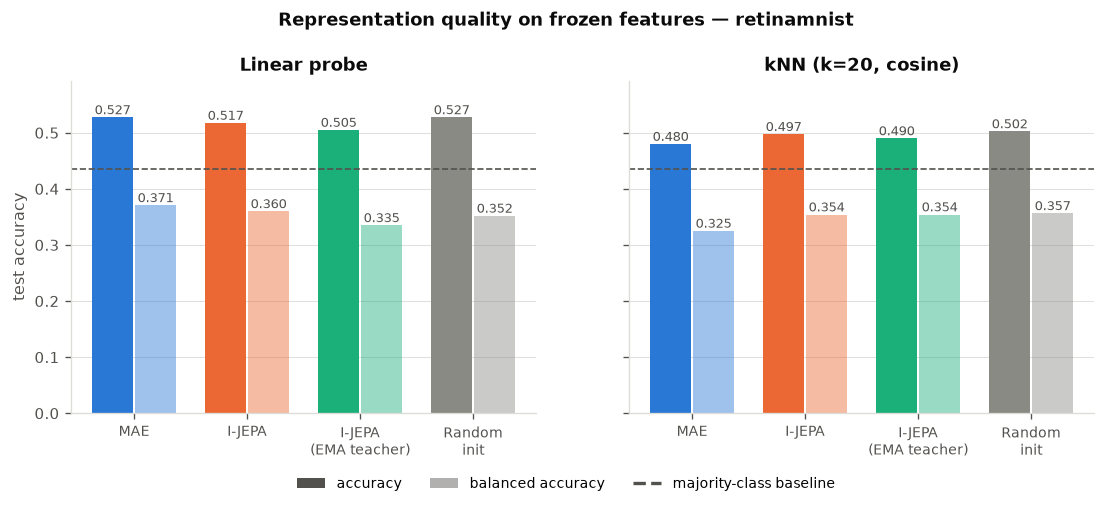

In [47]:
# Same numbers as a grouped bar chart. Direct value labels on every bar, so the aqua
# series never depends on color contrast alone to be readable. The legend distinguishes
# the two *metrics* (solid vs. faded) in neutral ink -- hue carries method identity, and
# a colored legend swatch here would claim otherwise.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.6), sharey=True)
names = [r[0] for r in rows]
xs = np.arange(len(names))
for ax, (title, ai, bi) in zip(axes, [("Linear probe", 1, 2), ("kNN (k=%d, cosine)" % CONFIG["knn_k"], 3, 4)]):
    acc = [r[ai] for r in rows]
    bacc = [r[bi] for r in rows]
    ax.bar(xs - 0.19, acc, width=0.36, color=[COLORS[n] for n in names])
    ax.bar(xs + 0.19, bacc, width=0.36, color=[COLORS[n] for n in names], alpha=0.45)
    for x, a, b in zip(xs, acc, bacc):
        ax.text(x - 0.19, a, f"{a:.3f}", ha="center", va="bottom", fontsize=8, color=INK2)
        ax.text(x + 0.19, b, f"{b:.3f}", ha="center", va="bottom", fontsize=8, color=INK2)
    ax.axhline(MAJORITY_ACC, color=INK2, linestyle="--", linewidth=1.0)
    ax.set_ylim(0, max(max(acc), max(bacc)) * 1.18)  # headroom for the value labels
    ax.set_xticks(xs)
    ax.set_xticklabels([n.replace(" (EMA teacher)", "\n(EMA teacher)").replace(" init", "\ninit")
                        for n in names], fontsize=8.5)
    ax.set_title(title)
    style_axes(ax)
axes[0].set_ylabel("test accuracy")
# Legend lives below the panels so it can never sit on top of a bar or its value label.
fig.legend(
    handles=[Patch(facecolor=INK2, label="accuracy"),
             Patch(facecolor=INK2, alpha=0.45, label="balanced accuracy"),
             Line2D([], [], color=INK2, linestyle="--", label="majority-class baseline")],
    loc="lower center", bbox_to_anchor=(0.5, -0.10), ncols=3, fontsize=8.5,
)
fig.suptitle(f"Representation quality on frozen features — {DATA_FLAG}",
             fontsize=11, fontweight="bold", color=INK, y=1.04)
save_fig(fig, "08_probe_comparison.png")
plt.show()

---
## 7. MAE reconstructions — and the picture JEPA cannot produce

This is the most intuitive output in the notebook. Left: the original test image.
Middle: what the encoder actually saw — 75% of the patches deleted. Right: the
reconstruction, with the visible patches pasted back in (standard practice; the decoder
only ever predicted the gray squares).

At this budget — a 2.7M-parameter encoder, 100 epochs, a thousand 64x64 images — expect
blurry blobs that get the retina's global structure roughly right and the fine vessel
detail wrong. **That blur is informative, not a failure.** Squared error is minimized by
predicting the conditional *mean* of the missing pixels, and when a patch is genuinely
ambiguous the mean of all plausible completions is a smear. MAE spends capacity learning
to hedge about pixel values.

[saved] outputs/09_mae_reconstructions.png


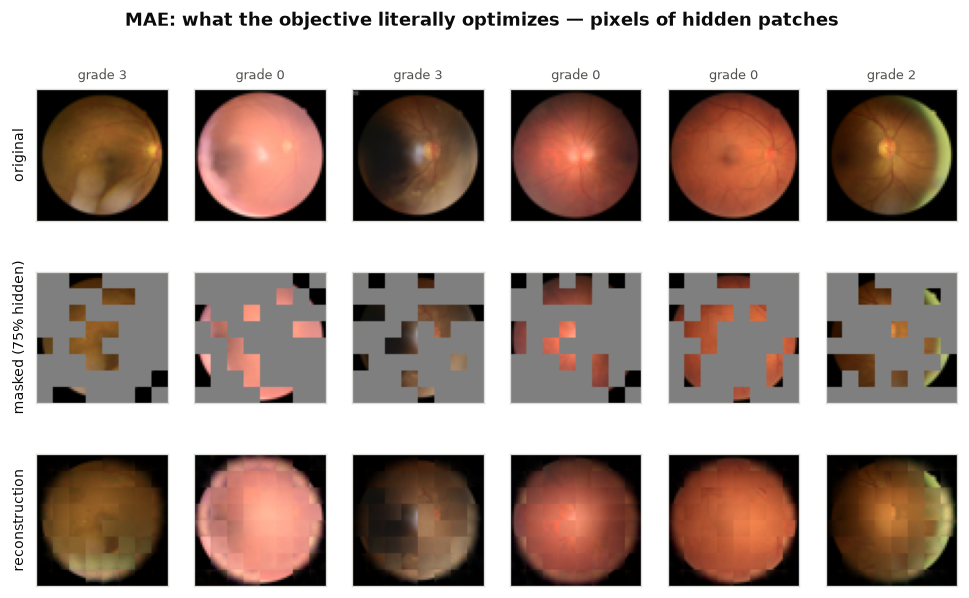

In [48]:
@torch.no_grad()
def mae_reconstruct(model: MAE, imgs01: torch.Tensor, seed: int = 0):
    """Returns (masked_view, reconstruction) as displayable [0,1] tensors."""
    model.eval()
    x_norm = ((imgs01 - MEAN_T) / STD_T).to(DEVICE, dtype=torch.float32)
    g = torch.Generator().manual_seed(seed)  # CPU generator (see random_masking)
    latent, mask, ids_restore = model.forward_encoder(x_norm, CONFIG["mae_mask_ratio"], g)
    pred = model.forward_decoder(latent, ids_restore)  # (B,N,patch_dim)

    if model.norm_pix_loss:
        # Predictions live in per-patch standardized space. To SHOW them we must undo
        # that using the ground-truth patch mean/var -- so this view is slightly generous
        # to the model. Set mae_norm_pix_loss=False for an unassisted picture.
        tgt = model.patchify(x_norm)
        mu = tgt.mean(dim=-1, keepdim=True)
        var = tgt.var(dim=-1, keepdim=True)
        pred = pred * (var + 1e-6).sqrt() + mu

    patches = model.patchify(x_norm)
    m = mask.unsqueeze(-1)  # 1 = was hidden
    masked_view = model.unpatchify(patches * (1 - m))  # hidden patches -> 0 (normalized)
    pasted = model.unpatchify(patches * (1 - m) + pred * m)

    def denorm(t):
        return (t.detach().cpu() * STD_T + MEAN_T).clamp(0, 1)

    # For the masked view, paint hidden patches mid-gray instead of "normalized zero".
    mv = denorm(masked_view)
    gray_mask = model.unpatchify(m.expand(-1, -1, model.patch_dim).float()).cpu()
    mv = mv * (1 - gray_mask) + 0.5 * gray_mask
    return mv, denorm(pasted)


n_vis = 6
vis_idx = np.random.RandomState(3).choice(len(EVAL_IMGS["test"]), n_vis, replace=False)
vis_imgs = EVAL_IMGS["test"][vis_idx]
masked_view, recon = mae_reconstruct(mae_model, vis_imgs, seed=CONFIG["seed"])

fig, axes = plt.subplots(3, n_vis, figsize=(1.65 * n_vis, 5.6))
row_titles = ["original", f"masked ({int(CONFIG['mae_mask_ratio'] * 100)}% hidden)",
              "reconstruction"]
for j in range(n_vis):
    for i, im in enumerate([vis_imgs[j], masked_view[j], recon[j]]):
        ax = axes[i, j]
        ax.imshow(im.permute(1, 2, 0).numpy())
        ax.set_xticks([]), ax.set_yticks([])
        for s in ax.spines.values():
            s.set_color(GRID)
        if j == 0:
            ax.set_ylabel(row_titles[i], fontsize=8.5, color=INK, rotation=90, labelpad=6)
    axes[0, j].set_title(f"grade {EVAL_LABELS['test'][vis_idx[j]]}", fontsize=8,
                         fontweight="normal", color=INK2)
fig.suptitle("MAE: what the objective literally optimizes — pixels of hidden patches",
             fontsize=11, fontweight="bold", color=INK, y=0.98)
save_fig(fig, "09_mae_reconstructions.png")
plt.show()

### I-JEPA has no equivalent figure, and that is the whole point

There is no "JEPA reconstruction" grid in this notebook because **there is nothing to
draw.** JEPA's predictor outputs a 192-dimensional vector per hidden patch, trained to
match what the EMA teacher computes for that patch. Those vectors are not pixels and
there is no decoder anywhere in the model that could turn them into pixels. You could
bolt one on afterwards, but it would be a separate model answering a separate question —
not a window into the objective.

This is the structural difference, stated as plainly as it can be:

- **MAE's target lives in pixel space.** Pixel space is fully specified: every value the
  sensor recorded, signal and noise alike, is part of the target. Getting the loss down
  means accounting for all of it.
- **JEPA's target lives in a learned latent space** — a space the model is simultaneously
  shaping. Anything the teacher's features *discard* simply stops being part of the
  objective. The model is allowed to decide that some of the input doesn't matter.

That's an appealing story. Section 8 checks whether it actually shows up at this scale.

A caveat on the picture above rather than the argument: interpretability and
representation quality are different axes. MAE's reconstructions are legible *and*
MAE's features may or may not be better here — the grid tells you what the loss cares
about, not who wins.

---
## 8. Noise robustness — the key experiment

The mechanistic story predicts something testable. If MAE's objective forces it to model
every pixel including the noise, its features should carry noise-sensitive components. If
JEPA's latent target lets it discard what the teacher discards, its features should be
steadier as the input degrades.

**The protocol matters, so read it before the plot.** For each noise level sigma:

1. Fit the probe **once, on CLEAN train features.** The classifier never sees noise.
2. Corrupt only the **test** images, re-extract features through the frozen encoder,
   and score.

This measures the **encoder's** stability, not the classifier's ability to adapt — which
is what we actually want to know about a representation. Noise is added in pixel space
before normalization, and clamped to [0,1], so sigma reads as a fraction of the dynamic
range. Every method sees the **same** noise realisation (fixed seed).

Two noise types:
- **Gaussian (additive)** — the standard sensor-noise stand-in.
- **Speckle (multiplicative,** `x + x*sigma*eps`**)** — scales with local intensity, which
  is much closer to what degrades ultrasound and OCT. Bright structures get corrupted
  more than dark background, so it interacts with anatomy rather than sitting on top of it.

**Read the curves two ways.** Absolute accuracy answers "which features are more useful
at this noise level". The *retention ratio* — accuracy(sigma) / accuracy(0), printed below
— answers "which features degrade more gracefully". A method can start lower and still be
the more robust one, and those are different claims.

In [49]:
NOISE_KINDS = ("gaussian", "speckle")
noise_results = {k: {n: {"linear": [], "knn": []} for n in ENCODERS} for k in NOISE_KINDS}

with Phase("8. noise-robustness sweep"):
    total = len(NOISE_KINDS) * len(CONFIG["noise_sigmas"]) * len(ENCODERS)
    with tqdm(total=total, desc="noise sweep") as pbar:
        for kind in NOISE_KINDS:
            for sigma in CONFIG["noise_sigmas"]:
                for name, enc in ENCODERS.items():
                    ftr = CLEAN[name]["train"]  # probe ALWAYS fit on clean train features
                    fte = (CLEAN[name]["test"] if sigma == 0
                           else extract_features(enc, EVAL_IMGS["test"], kind, sigma))
                    noise_results[kind][name]["linear"].append(
                        linear_probe(ftr, y_train, fte, y_test)["acc"])
                    noise_results[kind][name]["knn"].append(
                        knn_probe(ftr, y_train, fte, y_test)["acc"])
                    pbar.update(1)

sig = list(CONFIG["noise_sigmas"])
lines = [f"Noise robustness — probes fit on CLEAN train features, tested on NOISY test features",
         f"sigma values: {sig}"]
for kind in NOISE_KINDS:
    for probe in ("linear", "knn"):
        lines.append(f"\n[{kind} / {probe}]  accuracy   (retention vs sigma=0 in parens)")
        for name in ENCODERS:
            v = noise_results[kind][name][probe]
            base = v[0] if v[0] > 0 else float("nan")
            cells = "  ".join(f"{a:.3f}({a / base:.2f})" for a in v)
            lines.append(f"  {name:<22s} {cells}")
noise_table = "\n".join(lines)
print(noise_table)
(OUTDIR / "noise_table.txt").write_text(noise_table + "\n")
print(f"\n[saved] {OUTDIR / 'noise_table.txt'}")


=== 8. noise-robustness sweep ===


noise sweep:   0%|          | 0/48 [00:00<?, ?it/s]

=== 8. noise-robustness sweep: 9.3s wall-clock (0.16 min) ===
Noise robustness — probes fit on CLEAN train features, tested on NOISY test features
sigma values: [0.0, 0.05, 0.1, 0.2, 0.3, 0.4]

[gaussian / linear]  accuracy   (retention vs sigma=0 in parens)
  MAE                    0.527(1.00)  0.522(0.99)  0.465(0.88)  0.415(0.79)  0.390(0.74)  0.362(0.69)
  I-JEPA                 0.517(1.00)  0.482(0.93)  0.495(0.96)  0.490(0.95)  0.443(0.86)  0.388(0.75)
  I-JEPA (EMA teacher)   0.505(1.00)  0.490(0.97)  0.482(0.96)  0.460(0.91)  0.438(0.87)  0.427(0.85)
  Random init            0.527(1.00)  0.472(0.90)  0.435(0.82)  0.343(0.65)  0.300(0.57)  0.295(0.56)

[gaussian / knn]  accuracy   (retention vs sigma=0 in parens)
  MAE                    0.480(1.00)  0.485(1.01)  0.500(1.04)  0.463(0.96)  0.497(1.04)  0.500(1.04)
  I-JEPA                 0.497(1.00)  0.495(0.99)  0.505(1.02)  0.482(0.97)  0.460(0.92)  0.438(0.88)
  I-JEPA (EMA teacher)   0.490(1.00)  0.507(1.04)  0.502(1.03)  0.

[saved] outputs/10_noise_robustness.png


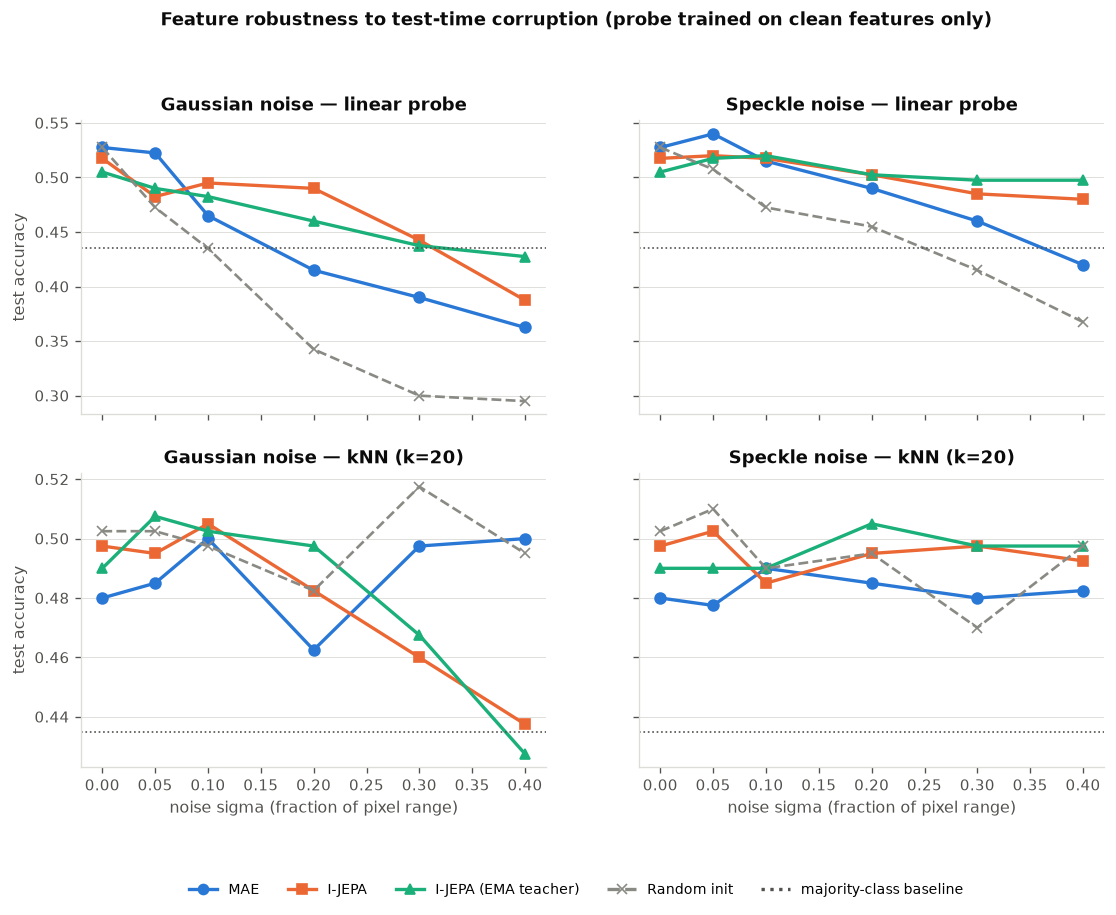

[saved] outputs/11_noise_retention.png


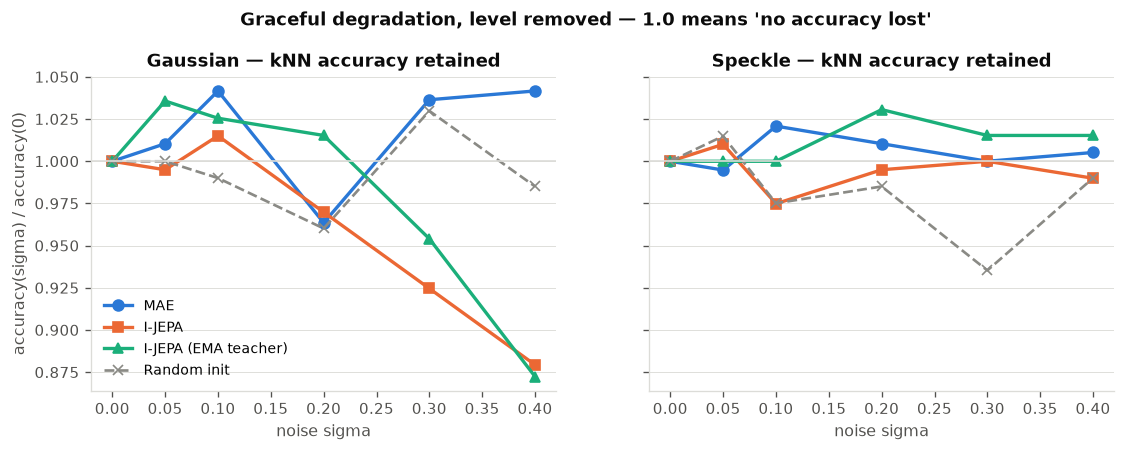

In [50]:
# sharey="row": the two noise types must sit on the SAME scale within a row, because the
# markdown below invites a gaussian-vs-speckle comparison at matched sigma. Independent
# y-scales would make that comparison meaningless.
fig, axes = plt.subplots(2, 2, figsize=(11.0, 7.0), sharex=True, sharey="row")
for r, probe in enumerate(("linear", "knn")):
    for c, kind in enumerate(NOISE_KINDS):
        ax = axes[r, c]
        for name in ENCODERS:
            ax.plot(sig, noise_results[kind][name][probe], color=COLORS[name],
                    marker=MARKERS[name], markersize=6.5, label=name,
                    linestyle="--" if name == "Random init" else "-",
                    linewidth=1.6 if name == "Random init" else 2.0)
        ax.axhline(MAJORITY_ACC, color=INK2, linestyle=":", linewidth=1.0)
        probe_label = "linear probe" if probe == "linear" else f"kNN (k={CONFIG['knn_k']})"
        ax.set_title(f"{kind.capitalize()} noise — {probe_label}")
        if r == 1:
            ax.set_xlabel("noise sigma (fraction of pixel range)")
        if c == 0:
            ax.set_ylabel("test accuracy")
        style_axes(ax)
handles = [Line2D([], [], color=COLORS[n], marker=MARKERS[n],
                  linestyle="--" if n == "Random init" else "-", label=n) for n in ENCODERS]
handles.append(Line2D([], [], color=INK2, linestyle=":", label="majority-class baseline"))
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncols=5, fontsize=8.5)
fig.suptitle("Feature robustness to test-time corruption (probe trained on clean features only)",
             fontsize=11, fontweight="bold", color=INK, y=1.01)
save_fig(fig, "10_noise_robustness.png")
plt.show()

# Retention view: every curve starts at 1.0, so the question becomes purely "how fast
# does it fall?" — the shape claim, separated from the level claim.
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.4), sharey=True)
for c, kind in enumerate(NOISE_KINDS):
    ax = axes[c]
    for name in ENCODERS:
        v = np.array(noise_results[kind][name]["knn"], dtype=float)
        ax.plot(sig, v / max(v[0], 1e-8), color=COLORS[name], marker=MARKERS[name],
                markersize=6.5, label=name,
                linestyle="--" if name == "Random init" else "-",
                linewidth=1.6 if name == "Random init" else 2.0)
    ax.axhline(1.0, color=GRID, linewidth=1.0)
    ax.set_title(f"{kind.capitalize()} — kNN accuracy retained")
    ax.set_xlabel("noise sigma")
    style_axes(ax)
axes[0].set_ylabel("accuracy(sigma) / accuracy(0)")
axes[0].legend(loc="lower left", fontsize=8.5)
fig.suptitle("Graceful degradation, level removed — 1.0 means 'no accuracy lost'",
             fontsize=11, fontweight="bold", color=INK, y=1.04)
save_fig(fig, "11_noise_retention.png")
plt.show()

### Reading these curves honestly

The claim under test is *"MAE fixates on pixel noise, JEPA ignores it."* Here is how to
decide what your run actually shows, without reading the conclusion into it.

**What would support the claim.** JEPA's curve flatter than MAE's in the retention plot —
same starting accuracy, slower decay — and the gap widening with sigma. The mechanism
would be exactly the one section 7 described: features trained to match a latent target
never had to represent per-pixel detail, so corrupting that detail moves them less.

**What would count against it.** The two curves falling in near-lockstep, or MAE's being
the flatter one. That is a perfectly real outcome at this scale and you should report it
as such. Three reasons it happens, all worth knowing:

- **Mean-pooling is already a strong low-pass filter.** Averaging 64 token vectors
  cancels a great deal of zero-mean pixel noise regardless of how the encoder was
  trained. The eval protocol itself supplies robustness that neither objective had to
  earn — and it hides differences between them.
- **Neither encoder learned much fine detail to begin with.** At 64x64 with a 2.7M-param
  ViT and 1,000 images, MAE's reconstructions are blurry (you saw them). A model that
  never represented high frequencies cannot lose them to noise. The "MAE fixates on
  pixels" failure mode needs a model with enough capacity to actually fixate.
- **Clamping to [0,1] plus per-channel normalization compresses the corruption.** By
  sigma=0.4 the images are visibly destroyed, but the clamp makes the damage saturating
  rather than unbounded.

**If the two probes disagree, believe the disagreement — it's information.** A likely
pattern here is that the **linear probe separates the methods while kNN stays flat**.
That is not a contradiction, and it's the most interesting thing these panels can show:

- A linear probe reads out *specific directions* in feature space. Noise that rotates
  features away from the learned decision hyperplane costs accuracy immediately, so the
  probe is sensitive to whether the encoder's geometry survives corruption.
- kNN only cares about the *ranking of pairwise distances*. Noise has to reorder
  neighbors to matter, and mean-pooling 64 tokens plus L2-normalizing leaves that
  ordering surprisingly intact — so kNN can look robust even when the feature space is
  being visibly deformed.

So: **the linear row is where a real robustness difference between the objectives will
show up first**, and the kNN row mostly tells you the coarse neighborhood structure is
holding. If linear separates and kNN doesn't, the honest reading is "the objectives
produce differently-shaped feature spaces, and the difference is in the fine geometry,
not the gross clustering."

**Watch the gray line.** If a *trained* encoder's curve sits near or below the random-init
control, that method's noise behavior is not telling you anything about its objective —
it is telling you the pretraining didn't take at this budget. Conversely, if both trained
methods degrade *more gracefully* than random init while starting from the same clean
accuracy, that is a genuine pretraining effect: same information at sigma=0, more robustly
encoded.

**The speckle panel is worth its own look.** Because speckle scales with intensity, it
preferentially destroys the bright optic disc and vessel reflections — the highest-contrast
landmarks in a fundus image. If one method holds up better under speckle than under
additive Gaussian noise at matched sigma, that suggests its features lean on
lower-contrast, more distributed structure. That's a genuinely medical-imaging-flavored
distinction, and it is the kind of thing this small experiment *can* legitimately hint at.

---
## 9. Sample efficiency — how many labels do you actually need?

The practical promise of self-supervised pretraining in medicine is not peak accuracy; it
is **getting acceptable accuracy from few labels**, because expert annotation is the
scarce resource. So we sweep the number of labeled training examples — 1% to 100% —
holding the frozen features fixed and refitting only the probe.

Details that keep this honest:

- Subsamples are **stratified**, so a 1% draw still contains every grade it can.
- Each fraction is repeated `label_repeats` times with different draws; we plot the mean
  with a ±1 s.d. band. At 1% of RetinaMNIST that's ~10 images, where a single unlucky
  draw swings accuracy by tens of points — a single-draw curve at that end would be
  almost pure noise.
- kNN's `k` shrinks automatically when the labeled set is smaller than k.

**What to look for:** not the right edge (that's section 6 again) but the **left** edge
and the **shape**. A method whose curve rises faster is the one whose features have
organized the data more usefully before any labels arrived. And again: if a curve tracks
the gray random-init line across the whole sweep, pretraining bought nothing here.

In [51]:
from sklearn.model_selection import train_test_split

fracs = list(CONFIG["label_fractions"])
sample_results = {n: {"linear": [], "knn": [], "linear_sd": [], "knn_sd": []} for n in ENCODERS}
n_train_total = len(y_train)

with Phase("9. sample-efficiency sweep"):
    with tqdm(total=len(fracs) * len(ENCODERS), desc="label fractions") as pbar:
        for f in fracs:
            n_sub = max(NUM_CLASSES, int(round(f * n_train_total)))
            for name in ENCODERS:
                lin_runs, knn_runs = [], []
                for rep in range(CONFIG["label_repeats"]):
                    if n_sub >= n_train_total:
                        idx = np.arange(n_train_total)
                    else:
                        try:  # stratified where possible
                            idx, _ = train_test_split(
                                np.arange(n_train_total), train_size=n_sub,
                                stratify=y_train, random_state=100 + rep)
                        except ValueError:
                            idx = np.random.RandomState(100 + rep).choice(
                                n_train_total, n_sub, replace=False)
                    ftr, ytr = CLEAN[name]["train"][idx], y_train[idx]
                    lin_runs.append(linear_probe(ftr, ytr, CLEAN[name]["test"], y_test)["acc"])
                    knn_runs.append(knn_probe(ftr, ytr, CLEAN[name]["test"], y_test)["acc"])
                    if n_sub >= n_train_total:  # deterministic; no point repeating
                        break
                sample_results[name]["linear"].append(np.nanmean(lin_runs))
                sample_results[name]["knn"].append(np.nanmean(knn_runs))
                sample_results[name]["linear_sd"].append(np.nanstd(lin_runs))
                sample_results[name]["knn_sd"].append(np.nanstd(knn_runs))
                pbar.update(1)

n_labels = [max(NUM_CLASSES, int(round(f * n_train_total))) for f in fracs]
lines = ["Sample efficiency — frozen features, probe refit on a stratified label subset",
         f"fractions {fracs}", f"n labels  {n_labels}"]
for probe in ("linear", "knn"):
    lines.append(f"\n[{probe}] mean accuracy over {CONFIG['label_repeats']} draws (sd)")
    for name in ENCODERS:
        cells = "  ".join(f"{m:.3f}({s:.3f})" for m, s in
                          zip(sample_results[name][probe], sample_results[name][probe + "_sd"]))
        lines.append(f"  {name:<22s} {cells}")
sample_table = "\n".join(lines)
print(sample_table)
(OUTDIR / "sample_efficiency_table.txt").write_text(sample_table + "\n")
print(f"\n[saved] {OUTDIR / 'sample_efficiency_table.txt'}")


=== 9. sample-efficiency sweep ===


label fractions:   0%|          | 0/28 [00:00<?, ?it/s]

=== 9. sample-efficiency sweep: 1.3s wall-clock (0.02 min) ===
Sample efficiency — frozen features, probe refit on a stratified label subset
fractions [0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 1.0]
n labels  [11, 22, 54, 108, 270, 540, 1080]

[linear] mean accuracy over 3 draws (sd)
  MAE                    0.464(0.031)  0.443(0.020)  0.457(0.005)  0.487(0.005)  0.504(0.016)  0.538(0.014)  0.527(0.000)
  I-JEPA                 0.445(0.027)  0.464(0.011)  0.460(0.007)  0.474(0.008)  0.518(0.028)  0.505(0.025)  0.517(0.000)
  I-JEPA (EMA teacher)   0.440(0.009)  0.450(0.013)  0.472(0.007)  0.472(0.005)  0.501(0.014)  0.510(0.013)  0.505(0.000)
  Random init            0.396(0.050)  0.419(0.029)  0.476(0.015)  0.470(0.022)  0.492(0.030)  0.511(0.004)  0.527(0.000)

[knn] mean accuracy over 3 draws (sd)
  MAE                    0.465(0.024)  0.470(0.036)  0.498(0.035)  0.487(0.016)  0.502(0.012)  0.499(0.010)  0.480(0.000)
  I-JEPA                 0.468(0.005)  0.475(0.028)  0.512(0.030)  0.512(0

[saved] outputs/12_sample_efficiency.png


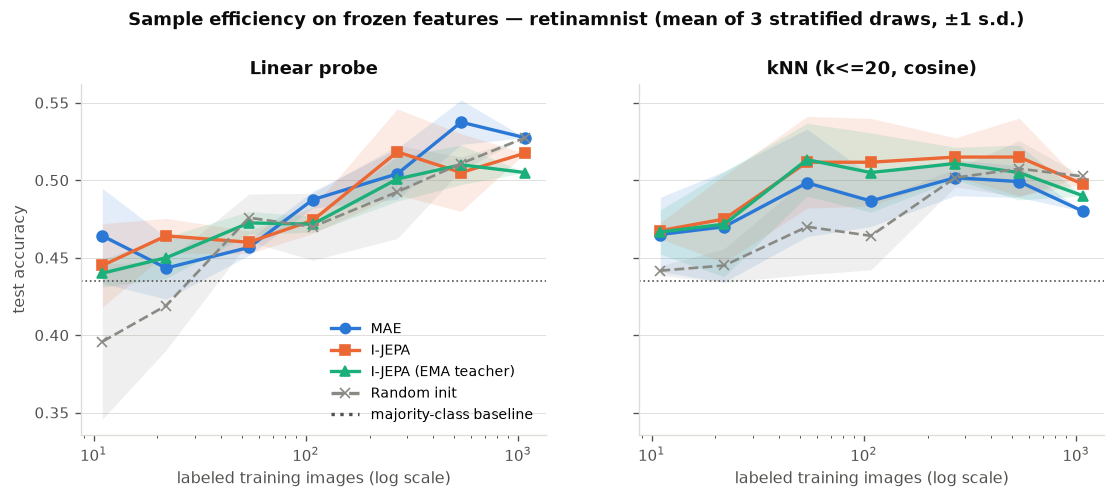

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8), sharey=True)
for ax, probe, title in zip(axes, ("linear", "knn"),
                            ("Linear probe", f"kNN (k<={CONFIG['knn_k']}, cosine)")):
    for name in ENCODERS:
        m = np.array(sample_results[name][probe], dtype=float)
        s = np.array(sample_results[name][probe + "_sd"], dtype=float)
        ax.plot(n_labels, m, color=COLORS[name], marker=MARKERS[name], markersize=6.5,
                label=name, linestyle="--" if name == "Random init" else "-",
                linewidth=1.6 if name == "Random init" else 2.0)
        ax.fill_between(n_labels, m - s, m + s, color=COLORS[name], alpha=0.13, linewidth=0)
    ax.axhline(MAJORITY_ACC, color=INK2, linestyle=":", linewidth=1.0)
    ax.set_xscale("log")
    ax.set_xlabel("labeled training images (log scale)")
    ax.set_title(title)
    style_axes(ax)
axes[0].set_ylabel("test accuracy")
axes[0].legend(handles=[
    *[Line2D([], [], color=COLORS[n], marker=MARKERS[n],
             linestyle="--" if n == "Random init" else "-", label=n) for n in ENCODERS],
    Line2D([], [], color=INK2, linestyle=":", label="majority-class baseline"),
], loc="lower right", fontsize=8.5)
fig.suptitle(f"Sample efficiency on frozen features — {DATA_FLAG} "
             f"(mean of {CONFIG['label_repeats']} stratified draws, ±1 s.d.)",
             fontsize=11, fontweight="bold", color=INK, y=1.04)
save_fig(fig, "12_sample_efficiency.png")
plt.show()

In [53]:
print("wall-clock per phase")
print("-" * 46)
for k, v in TIMINGS.items():
    print(f"{k:<34s} {v:>7.1f}s")
print("-" * 46)
print(f"{'TOTAL':<34s} {sum(TIMINGS.values()):>7.1f}s  ({sum(TIMINGS.values()) / 60:.1f} min)")
print("\nfiles written to ./outputs/:")
for p in sorted(OUTDIR.iterdir()):
    print(f"  {p.name}")

wall-clock per phase
----------------------------------------------
2. load dataset                        0.1s
4. MAE pretraining                    66.7s
5. I-JEPA pretraining                151.2s
6. feature extraction (clean)          2.7s
6. linear + kNN probes                 0.2s
8. noise-robustness sweep              9.3s
9. sample-efficiency sweep             1.3s
----------------------------------------------
TOTAL                                231.6s  (3.9 min)

files written to ./outputs/:
  .ipynb_checkpoints
  01_dataset_samples.png
  02_class_balance.png
  03_lr_schedule.png
  04_mae_loss.png
  05_jepa_masking.png
  06_jepa_loss_and_collapse.png
  07_both_loss_curves.png
  08_probe_comparison.png
  09_mae_reconstructions.png
  10_noise_robustness.png
  11_noise_retention.png
  12_sample_efficiency.png
  noise_table.txt
  results_table.txt
  sample_efficiency_table.txt


---
## 10. Honest caveats, and what actually transfers

### Read this before you conclude anything from the numbers above

**At this scale and budget, I-JEPA may well not beat MAE — and that is a real result, not
a broken experiment.** I-JEPA's reported advantages were established on ImageNet-scale
data with ViT-Large/Huge encoders, hundreds of epochs, large batches, and a masking
configuration tuned for 224x224 inputs. Essentially every ingredient it depends on is
absent here:

- **Data.** ~1,080 pretraining images against ImageNet's 1.28M. Latent-target methods are
  the *hungrier* of the two families: the teacher's features have to become meaningful
  before predicting them is a meaningful task. MAE's pixel target is well-defined from
  step one, which makes it the more forgiving objective in the small-data regime.
- **EMA sensitivity.** JEPA's behavior depends on the interaction of momentum, batch size,
  and total steps. With 16 steps per epoch, a momentum of 0.996 means the teacher has an
  effective horizon of hundreds of steps — tens of epochs. It is plausibly still
  catching up when training ends. The collapse monitor in section 5 tells you the run
  was stable; it does not tell you the schedule was well-matched.
- **Masking geometry.** On an 8x8 grid, a "block at scale 0.15" is roughly 3x3 patches.
  I-JEPA's block masking was designed so that a target region is large enough to require
  semantic inference but small enough to be predictable. At this grid resolution there
  simply isn't much room for that distinction to exist.
- **Evaluation noise.** 400 test images means one image is 0.25% accuracy. Mean-pooled
  features plus a 5-class imbalanced ordinal task plus MPS non-determinism: **treat any
  gap under ~2-3 points as indistinguishable from zero.** Not "a small win" — no win.

**The random-init row is your reality check.** If both methods sit near it on clean
accuracy, any MAE-vs-JEPA ordering you read off that table is noise being
over-interpreted. Check that row first, every time.

**But "same clean accuracy as random init" does not mean "learned nothing."** This is the
subtlest thing in the notebook, so it gets its own paragraph. On a 400-image, 5-class,
imbalanced test set, mean-pooled features from *any* reasonable ViT — trained or not — land
in a narrow band around the majority-class baseline; the ceiling is set by the task and
the eval protocol, not by the encoder. The clean-accuracy column is therefore a **low-
resolution instrument**: it can be saturated and uninformative while the representations
underneath differ substantially. Sections 8 and 9 are higher-resolution probes of the
same features, and they can register a clear pretraining effect — better noise retention,
better accuracy in the few-label regime — while section 6's table looks flat. If you see
that combination, the correct conclusion is "pretraining changed the features in ways
clean top-1 on this test set cannot see", not "pretraining did nothing."

### What does transfer — the mechanics

These are true independently of who won on your run:

1. **Where the target lives determines what the model must represent.** MAE's target is
   pixels: fully specified, includes the noise, and the loss is minimized by predicting a
   conditional mean (hence the blur). JEPA's target is a learned latent: whatever the
   teacher discards leaves the objective entirely. This single choice drives everything
   else.
2. **A latent target needs a stabilizer or it collapses.** Predicting your own
   representation admits the trivial constant solution. Stop-gradient + an EMA teacher is
   what makes it a real task — the student cannot move the goalposts, and the goalposts
   move too slowly to be chased into degeneracy. Section 5's `target_std` curve is that
   mechanism made visible.
3. **Asymmetric capacity is a design tool, not an accident.** MAE's decoder is shallow so
   the encoder can't outsource the work; JEPA's predictor is narrow for the same reason.
   In both cases the throwaway module is deliberately weakened.
4. **Interpretability and quality are different axes.** MAE gives you a picture of what
   it optimizes; JEPA structurally cannot. That makes MAE far easier to debug and says
   nothing about which features are better.
5. **How you evaluate can erase the effect you're measuring.** Mean-pooling over tokens
   low-passes exactly the noise section 8 injects. That's worth knowing as a general
   habit: an eval protocol can quietly supply the property you were trying to attribute
   to the model.

### Get a stronger signal

In the CONFIG cell, change one line:

```python
"dataset": "pathmnist",   # 89,996 train images, 9 classes — ~80x more pretraining data
```

Then Run All. Nothing else needs editing: splits, class count, normalization statistics,
probes, and every plot are all derived from the dataset. Expect a substantially longer
run (steps per epoch scale with dataset size — consider dropping `epochs` to ~30 for a
first pass, which still gives far more gradient steps than 100 epochs of RetinaMNIST).
**This is the single highest-value change you can make**, because the honest summary of
a RetinaMNIST-only comparison is "too small to separate these methods."

Other knobs, in rough order of expected effect:

- `img_size: 128` with `patch_size: 16` — a 8x8 grid is coarse for block masking; more
  tokens gives the geometry room to matter. (At 128/8 you'd get 256 tokens and a much
  slower run.)
- `epochs` — 100 is short for either method. 300+ changes the picture, especially for
  JEPA, whose teacher needs time.
- `mae_norm_pix_loss: True` — the paper's default; usually helps the probe, at the cost of
  needing ground-truth patch statistics to display reconstructions.
- `jepa_ema: 0.99` — a faster teacher, which is often the right call when there are few
  steps per epoch.
- `jepa_target_scale`/`jepa_num_targets` — the most JEPA-specific lever there is. Larger
  or more numerous target blocks make the prediction task harder and more semantic.

### What this notebook is for

It is a mechanism explainer with real gradients flowing through it, not a benchmark. The
reconstruction grid, the collapse monitor, the masking visualization, and the noise
retention curves are the payload; the accuracy table is the least durable thing here.